# 025 — Switch Characterization Campaign (P6.8/P6.9)

Oscilloscope campaign on the CGC switch units (swB first, then swA) per
`raw/plans/2026-07-05-p6-cgc-explorer.md` section D. Runs on the P6.8
lab classes (`PSU`/`SW`/`SWHR` on `CGCDevice`) and the campaign tooling
in `devices.cgc.campaign`.

## SAFETY — non-negotiable (CGC email, notebook 023)

- Per-switch-channel dissipation **< 100 W** (pair <= 200 W).
- At 350 V: output current **<= 300 mA**.
- **Recipe order:** ramp voltage at **1 kHz** up to the target (<= 350 V)
  FIRST, **then** ramp frequency at full voltage.
- The `PSUWatchdog` polls PSU readback between steps: breach -> 10 %
  step-down, second consecutive breach -> outputs disabled. It is a SOFT
  watchdog — it does not replace watching the current readout.
- Bring-up and teardown go through **NVM configs** (notebook 023):
  switch config -> PSU configs -> scope verify -> function-based
  moves; standby config (python 0) back at every block end. Python
  indices are 0-based: `load_current_config(N)` = file
  `[Configuration N+1]`.
- Broken sensors: **swA sensor 2, swB sensor 0** (skipped in housekeeping
  and plots).

## Wiring (notebook 023, authoritative)

| Switch | Outputs | PSU | Load |
|---|---|---|---|
| swB (SW)   | 0/1 | psu2 | Quadrupole 1 |
| swB (SW)   | 2/3 | psu1 | Ion Funnels |
| swA (SWHR) | 0/1 | psu3 | Quadrupole 2 |
| swA (SWHR) | 2/3 | psu4 | Quadrupoles 3/4 |

## SIM mode

`SIM = True` (default) builds every device with `test_mode=True`: no DLL,
no COM ports, all helpers run against the stateful sims — the P6.8
dry-run. Set `SIM = False` only at the bench, with Explorer closed
(one COM port, one owner) and the printed checklist from
`raw/guides/switch-operation-guide.md` on the table.

In [1]:
import sys
import os
import time
import logging
from datetime import datetime
from pathlib import Path

# --- The one switch that matters ---------------------------------------
SIM = False   # True: test_mode devices, zero hardware. False: THE BENCH.

# Add src to path
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'src'))

from devices.cgc import PSU, SW, SWHR
from devices.cgc.campaign import (
    PSUWatchdog, WatchdogBreach, ramp_voltage_at_1khz, ramp_frequency,
    I_LIMIT_MA, P_LIMIT_W, RAMP_FREQ_KHZ, V_MAX,
)

# Canonical COM ports (lab_services/lab_config.toml [com_ports]); the
# fallback matches the table confirmed by the user 2026-07-03.
COM = {"PSU1": 15, "PSU2": 16, "PSU3": 17, "PSU4": 18, "swA": 9, "swB": 10}
try:
    import tomllib
    _cfg = Path(os.getcwd()) / ".." / ".." / ".." / "lab_services" / "lab_config.toml"
    with open(_cfg, "rb") as f:
        _ports = tomllib.load(f)["com_ports"]
    COM.update({k: _ports[k] for k in COM if k in _ports})
    print(f"COM ports from lab_config.toml: {COM}")
except Exception as e:
    print(f"lab_config.toml not readable ({e}) - using fallback table {COM}")

print(f"SIM = {SIM}   limits: {I_LIMIT_MA:.0f} mA / {P_LIMIT_W:.0f} W, "
      f"ramp at {RAMP_FREQ_KHZ:.0f} kHz, ceiling {V_MAX:.0f} V")

COM ports from lab_config.toml: {'PSU1': 15, 'PSU2': 16, 'PSU3': 17, 'PSU4': 18, 'swA': 9, 'swB': 10}
SIM = False   limits: 300 mA / 100 W, ramp at 1 kHz, ceiling 350 V


In [2]:
# Session logger: one file per campaign day + console.
logs_dir = Path(os.getcwd()) / ".." / "logs"
logs_dir.mkdir(parents=True, exist_ok=True)
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
logger = logging.getLogger(f"campaign_{stamp}")
logger.setLevel(logging.DEBUG)
if not logger.handlers:
    fh = logging.FileHandler(logs_dir / f"025_switch_campaign_{stamp}.log")
    fh.setFormatter(logging.Formatter("%(asctime)s %(levelname)-7s %(message)s"))
    fh.setLevel(logging.DEBUG)
    logger.addHandler(fh)
    console_handler = logging.StreamHandler()
    console_handler.setFormatter(logging.Formatter("%(levelname)-7s %(message)s"))
    console_handler.setLevel(logging.INFO)
    logger.addHandler(console_handler)
logger.info(f"campaign session start, SIM={SIM}")

INFO    campaign session start, SIM=False


## Devices

All six instruments; broken sensors skipped per unit.

In [3]:
psu1 = PSU("psu1", com=COM["PSU1"], port=0, logger=logger, test_mode=SIM)
psu2 = PSU("psu2", com=COM["PSU2"], port=1, logger=logger, test_mode=SIM)
psu3 = PSU("psu3", com=COM["PSU3"], port=2, logger=logger, test_mode=SIM)
psu4 = PSU("psu4", com=COM["PSU4"], port=3, logger=logger, test_mode=SIM)
swA = SWHR("swA", com=COM["swA"], stream=0, logger=logger, test_mode=SIM,
           skip_sensors=(2,))   # sensor 2 broken
swB = SW("swB", com=COM["swB"], port=0, logger=logger, test_mode=SIM,
         skip_sensors=(0,))     # sensor 0 broken

PSUS = [psu1, psu2, psu3, psu4]
ALL = [("psu1", psu1), ("psu2", psu2), ("psu3", psu3), ("psu4", psu4),
       ("swA", swA), ("swB", swB)]

# Feeding map (wiring table above): switch unit -> its two PSUs.
FEEDS = {"swB": (psu2, psu1), "swA": (psu3, psu4)}

INFO    psu1          COM15  initialized (230400 baud)
INFO    psu2          COM16  initialized (230400 baud)
INFO    psu3          COM17  initialized (230400 baud)
INFO    psu4          COM18  initialized (230400 baud)
INFO    swA           COM9   initialized (230400 baud)
INFO    swB           COM10  initialized (230400 baud)


In [4]:
# Connect everything + read-back check (temps prove the wire).
for name, dev in ALL:
    ok = dev.connect()
    print(f"{name:5s} connect: {ok}")
for name, dev in ALL:
    with dev.thread_lock:
        status, t0, t1, t2 = dev.get_sensor_data()
    print(f"{name:5s} temps: {t0:.1f} / {t1:.1f} / {t2:.1f} degC (status {status})")

INFO    psu1          COM15  comspeed set to 230400
INFO    psu1          COM15  connected (vendor DLL, 230400 baud)
INFO    psu2          COM16  comspeed set to 230400
INFO    psu2          COM16  connected (vendor DLL, 230400 baud)


psu1  connect: True
psu2  connect: True


INFO    psu3          COM17  comspeed set to 230400
INFO    psu3          COM17  connected (vendor DLL, 230400 baud)
INFO    psu4          COM18  comspeed set to 230400
INFO    psu4          COM18  connected (vendor DLL, 230400 baud)


psu3  connect: True
psu4  connect: True


INFO    swA           COM9   comspeed set to 230400
INFO    swA           COM9   connected (vendor DLL, 230400 baud)
INFO    swB           COM10  comspeed set to 230400
INFO    swB           COM10  connected (vendor DLL, 230400 baud)


swA   connect: True
swB   connect: True
psu1  temps: 20.7 / 20.2 / 20.6 degC (status 0)
psu2  temps: 21.4 / 20.4 / 20.8 degC (status 0)
psu3  temps: 20.4 / 21.3 / 20.9 degC (status 0)
psu4  temps: 21.5 / 20.9 / 21.0 degC (status 0)
swA   temps: 20.6 / 20.6 / 0.2 degC (status 0)
swB   temps: 0.2 / 20.6 / 20.5 degC (status 0)


## Watchdog

`dog.check()` polls every PSU output once; the ramp helpers call it after
every step. Leave a manual `dog.check()` in scope while probing so you can
poll between scope shots.

In [5]:
dog = PSUWatchdog(PSUS)
breaches = dog.check()
print("watchdog:", "ALL CLEAR" if not breaches else breaches)

watchdog: ALL CLEAR


## Live monitor (Bokeh, opens in Chrome)

Temps left, per-PSU V/I right, 300 mA safety line — the notebook-023
monitor trimmed onto the curated lab-layer reads (so it animates in SIM
too). Set `RUN_LIVE_MONITOR = True` and run the cell; stop it by
interrupting the kernel or leaving it False for headless dry-runs.

**Locking rule (bench 2026-07-06):** this monitor thread polls every
device under `dev.thread_lock`. Every kernel-side DLL call in the
notebook must therefore also run inside `with dev.thread_lock:` — one
unlocked call is enough to cross frames on the wire, desync the RX
buffer and turn every following query into `-13` (`ERR_COMMAND_WRONG`)
until a `purge()` (same failure mode as the 2026-07-05 AMPR12 storm).
The campaign helpers + watchdog lock — and purge-retry — internally
since 2026-07-06; the M-cells wrap their direct calls.

In [6]:
RUN_LIVE_MONITOR = True   # True at the bench (and for a sim look)
BOKEH_PORT = 5008          # 023 used 5007

if RUN_LIVE_MONITOR:
    import threading
    import webbrowser
    from datetime import timedelta
    from bokeh.plotting import figure
    from bokeh.layouts import column, row
    from bokeh.models import ColumnDataSource, DatetimeTickFormatter, Range1d, Span
    from bokeh.palettes import Category10
    from bokeh.server.server import Server
    from tornado.ioloop import IOLoop

    PLOT_SENSORS = {"psu1": (0, 1, 2), "psu2": (0, 1, 2), "psu3": (0, 1, 2),
                    "psu4": (0, 1, 2), "swA": (0, 1), "swB": (1, 2)}
    WINDOW_MIN, MAX_POINTS = 5, 7200
    colors = Category10[3]

    def make_document(doc):
        temp_sources = {n: ColumnDataSource(
            data={"time": [], **{f"t{s}": [] for s in PLOT_SENSORS[n]}})
            for n, _ in ALL}
        psu_sources = {n: ColumnDataSource(
            data={"time": [], "v0": [], "v1": [], "i0": [], "i1": []})
            for n, d in ALL if isinstance(d, PSU)}
        now = datetime.now()
        x_range = Range1d(start=now - timedelta(minutes=WINDOW_MIN), end=now)
        fmt = DatetimeTickFormatter(seconds="%H:%M:%S", minsec="%H:%M:%S",
                                    minutes="%H:%M:%S", hourmin="%H:%M:%S",
                                    hours="%H:%M:%S")
        temp_figs, psu_figs = [], []
        for n, _ in ALL:
            p = figure(title=f"Temp: {n}", x_axis_type="datetime", height=160,
                       width=850, x_range=x_range)
            for s in PLOT_SENSORS[n]:
                p.line("time", f"t{s}", source=temp_sources[n], line_width=2,
                       color=colors[s], legend_label=f"Sensor {s}")
            p.xaxis.formatter = fmt
            p.legend.location = "top_left"
            p.legend.click_policy = "hide"
            temp_figs.append(p)
        for n in psu_sources:
            pi = figure(title=f"{n}: V (solid axis left) / I", height=200,
                        width=850, x_axis_type="datetime", x_range=x_range)
            pi.line("time", "i0", source=psu_sources[n], line_width=2,
                    color=colors[0], legend_label="I ch0 [mA]")
            pi.line("time", "i1", source=psu_sources[n], line_width=2,
                    color=colors[1], legend_label="I ch1 [mA]")
            pi.add_layout(Span(location=I_LIMIT_MA, dimension="width",
                               line_color="red", line_dash="dashed"))
            pi.xaxis.formatter = fmt
            pi.legend.location = "top_left"
            pi.legend.click_policy = "hide"
            psu_figs.append(pi)

        def update():
            now = datetime.now()
            for n, dev in ALL:
                try:
                    with dev.thread_lock:
                        status, t0, t1, t2 = dev.get_sensor_data()
                    if status != dev.NO_ERR:
                        continue
                    temps = (t0, t1, t2)
                    temp_sources[n].stream(
                        {"time": [now],
                         **{f"t{s}": [temps[s]] for s in PLOT_SENSORS[n]}},
                        rollover=MAX_POINTS)
                except Exception:
                    pass
            for n, dev in [(n, d) for n, d in ALL if isinstance(d, PSU)]:
                try:
                    with dev.thread_lock:
                        s0, v0, i0, _ = dev.get_psu_data(dev.PSU_POS)
                        s1, v1, i1, _ = dev.get_psu_data(dev.PSU_NEG)
                    psu_sources[n].stream(
                        {"time": [now], "v0": [v0], "v1": [v1],
                         "i0": [i0 * 1000.0], "i1": [i1 * 1000.0]},
                        rollover=MAX_POINTS)
                except Exception:
                    pass
            x_range.start = now - timedelta(minutes=WINDOW_MIN)
            x_range.end = now

        doc.add_periodic_callback(update, 1000)
        doc.add_root(row(column(*temp_figs), column(*psu_figs)))
        doc.title = "025 switch campaign"

    def run_server():
        server = Server({"/": make_document}, port=BOKEH_PORT,
                        io_loop=IOLoop())
        server.start()
        server.io_loop.start()

    threading.Thread(target=run_server, daemon=True).start()
    time.sleep(1.5)
    webbrowser.open(f"http://localhost:{BOKEH_PORT}/")
    print(f"live monitor on http://localhost:{BOKEH_PORT}/")
else:
    print("live monitor disabled (RUN_LIVE_MONITOR = False)")

live monitor on http://localhost:5008/


## Oscilloscope (R&S RTC1000 — raw SCPI over Ethernet)

Waveforms land directly in the notebook after every switch/PSU change —
no more reading numbers off the bench screen for the M-tables.

- **Transport:** raw TCP socket to `134.169.85.165:5025` (SCPI socket
  port, LF-terminated — manual ch. 12.1). Pure stdlib, no VISA/driver
  stack. The instrument's VISA string `TCPIP0::134.169.85.165::INSTR`
  reaches the same box via R&S VISA if that route is ever wanted.
- **Hookup (guide §2):** Mon0/Mon1 → CH1/CH2, **1:100 into 1 MΩ**
  (probe factor 100 is set via SCPI, so all readings below are real
  switch volts), DIO0 = PulsOut0 → TRIG IN (external edge trigger).
- **Polarity trap (§2):** a "Pos" trigger channel sits at the LOWER
  voltage while the pulser is HIGH — looks like swapped channels.
  Only complementarity matters; don't "fix" it.
- `scope_capture(label, meas=...)` = one synced `SINGle` acquisition →
  inline plot (CH1+CH2) + auto-measurements printed for the guide
  tables + trace CSV/PNG saved to `raw/switch-campaign/<date>/`.
- **SIM:** no scope behind the sim — `SCOPE = None`, all helpers no-op
  with a message, dry-run stays green.

Command set distilled from manual ch. 13 → `memory/devices/rtc1000-scope.md`.

In [7]:
import socket

import numpy as np
import matplotlib.pyplot as plt

SCOPE_IP = "134.169.85.165"   # SETUP > DEVICE INFORMATION on the scope
SCOPE_PORT = 5025             # SCPI raw-socket port (manual ch. 12.1)


class RTC1000:
    """Minimal raw-socket SCPI client for the R&S RTC1000 (manual ch. 13).

    Lowest level possible: stdlib socket, LF-terminated ASCII commands,
    IEEE 488.2 block data for binary transfers. No VISA, no drivers.
    Smoke-tested against the real RTC1002 (notebook 026, 2026-07-06).
    """

    def __init__(self, host=SCOPE_IP, port=SCOPE_PORT, timeout=5.0):
        self.sock = socket.create_connection((host, port), timeout=timeout)
        self.sock.settimeout(timeout)
        self._buf = b""

    def close(self):
        self.sock.close()

    # --- transport -----------------------------------------------------
    def cmd(self, command):
        """Send a set/event command (no response expected)."""
        self.sock.sendall(command.encode("ascii") + b"\n")

    def _recv_more(self):
        chunk = self.sock.recv(65536)
        if not chunk:
            raise ConnectionError("scope closed the connection")
        self._buf += chunk

    def query(self, command):
        """Send a query, return the ASCII response line (LF-terminated)."""
        self.cmd(command)
        while b"\n" not in self._buf:
            self._recv_more()
        line, self._buf = self._buf.split(b"\n", 1)
        return line.rstrip(b"\r").decode("ascii")

    def _read_exact(self, n):
        while len(self._buf) < n:
            self._recv_more()
        data, self._buf = self._buf[:n], self._buf[n:]
        return data

    def query_block(self, command):
        """Send a query, return IEEE 488.2 block data: #<n><len><bytes>."""
        self.cmd(command)
        head = self._read_exact(2)
        if head[:1] != b"#":
            raise ValueError(f"not block data: {head!r}")
        nbytes = int(self._read_exact(int(head[1:2])))
        data = self._read_exact(nbytes)
        # Consume the terminator after the block DETERMINISTICALLY: a lazy
        # lstrip races the socket, leaves the LF unread and desyncs every
        # later query by one (-410 Query INTERRUPTED - found by 026 T12).
        while b"\n" not in self._buf:
            self._recv_more()
        self._buf = self._buf.split(b"\n", 1)[1]
        return data

    # --- basics ----------------------------------------------------------
    def idn(self):
        return self.query("*IDN?")

    def errors(self):
        """Drain the error queue (0,'No error' = clean)."""
        return self.query("SYST:ERR:ALL?")

    def run(self):
        self.cmd("RUN")

    def single(self, timeout=15.0):
        """SINGle acquisition; *OPC? blocks until it completed (SINGle is
        asynchronous). Needs a trigger within <timeout> - at 1 kHz that is
        instant; raise it for very slow timebases."""
        old = self.sock.gettimeout()
        self.sock.settimeout(timeout)
        try:
            self.cmd("SINGle")
            self.query("*OPC?")
        finally:
            self.sock.settimeout(old)

    # --- waveform --------------------------------------------------------
    def waveform(self, ch=1, points="DEF", binary=False):
        """Waveform of channel <ch> -> (t [s], v [V]) numpy arrays.

        ASCII by default: the scope sends voltages directly, zero
        conversion ambiguity. binary=True switches to UINT,8 + the
        XOR/XINC/YOR/YINC conversion queries - the fast path for
        points="MAX" full-memory reads (RTC1002: 1048512 samples).
        Conversion verified vs ASCII on the real RTC1002 (026 T6,
        2026-07-06, live 3 V square: max deviation 0.0000 V).
        DATA:POINts is only valid while stopped - call single() first
        (manual: don't STOP a running acquisition for it).
        """
        self.cmd(f"CHAN{ch}:DATA:POIN {points}")
        xstart, xstop, n, vpi = self.query(f"CHAN{ch}:DATA:HEAD?").split(",")
        if binary:
            self.cmd("FORM UINT,8")
            self.cmd("FORM:BORD LSBF")
            yorg = float(self.query(f"CHAN{ch}:DATA:YOR?"))
            yinc = float(self.query(f"CHAN{ch}:DATA:YINC?"))
            raw = np.frombuffer(self.query_block(f"CHAN{ch}:DATA?"),
                                dtype=np.uint8)
            v = yorg + raw.astype(np.float64) * yinc
        else:
            self.cmd("FORM ASC")
            v = np.array(self.query(f"CHAN{ch}:DATA?").split(","),
                         dtype=np.float64)
        # int(vpi) == 2 means MIN/MAX display pairs per interval; a linear
        # time axis over all values is fine for plotting either way.
        t = np.linspace(float(xstart), float(xstop), v.size)
        return t, v

    # --- automatic measurements (fills the guide's M-tables) --------------
    def measure(self, mtype, source="CH1", place=1):
        """One auto-measurement, returns float (NaN if not measurable).

        mtype: FREQ | PER | PEAK | UPE | LPE | HIGH | LOW | AMPL | MEAN |
        RMS | RTIM | FTIM | PDCY | NDCY | PPW | NPW | POV | NOV | STDD |
        DEL | PHAS ... (manual 13.6.3). Two-source types (DEL, PHAS) take
        source="CH1,CH2"; edge slopes via MEAS<p>:DEL:SLOP.
        place: measurement slot 1..6 (parallel measurements keep slots).
        """
        self.cmd(f"MEAS{place} ON")
        self.cmd(f"MEAS{place}:SOUR {source}")
        self.cmd(f"MEAS{place}:MAIN {mtype}")
        val = float(self.query(f"MEAS{place}:RES?"))
        # 9.91e37 = R&S "measurement invalid" sentinel (seen on the real
        # RTC1002 with no signal, 026 T8) - surface it as NaN, not a number
        return float("nan") if abs(val) > 9e37 else val

    # --- screenshot --------------------------------------------------------
    def screenshot(self, path):
        """Save the scope display as PNG (HCOPy block data)."""
        self.cmd("HCOP:FORM PNG")
        Path(path).write_bytes(self.query_block("HCOP:DATA?"))
        return path

In [8]:
# Scope connect + campaign baseline. Bench-only: no simulator behind it.
SCOPE = None
TRACE_DIR = (Path(os.getcwd()) / ".." / ".." / ".." / "raw"
             / "switch-campaign" / datetime.now().strftime("%Y-%m-%d")).resolve()


def scope_setup_campaign(scope, v_per_div=100.0, t_per_div=200e-6,
                         trig_level=1.4):
    """Campaign baseline: both monitor channels with 1:100 probe factor
    (readings = real switch volts), edge trigger from DIO0 (= PulsOut0)
    on the external TRIG IN. NORMal mode: no trigger, no sweep."""
    for ch in (1, 2):
        scope.cmd(f"CHAN{ch}:STAT ON")
        scope.cmd(f"CHAN{ch}:COUP DCL")                # DC, 1 MOhm
        scope.cmd(f"PROB{ch}:SET:ATT:MAN 100")         # Mon out = 1:100
        scope.cmd(f"CHAN{ch}:SCAL {v_per_div}")        # V/div, real volts
        scope.cmd(f"CHAN{ch}:POS 0")
    scope.cmd(f"TIM:SCAL {t_per_div}")
    scope.cmd("TRIG:A:MODE NORM")
    scope.cmd("TRIG:A:TYPE EDGE")
    scope.cmd("TRIG:A:SOUR EXT")                       # EXTernanalog TRIG IN
    scope.cmd("TRIG:EXT:COUP DC")
    scope.cmd("TRIG:A:EDGE:SLOP POS")
    scope.cmd(f"TRIG:A:LEV5 {trig_level}")             # level slot 5 = ext
    print("scope setup, error queue:", scope.errors())


def scope_timebase_for(f_hz, periods=4):
    """Timebase so ~<periods> signal periods fill the 12 divisions."""
    if SCOPE is not None:
        SCOPE.cmd(f"TIM:SCAL {periods / f_hz / 12:.3e}")


def scope_capture(label, chs=(1, 2), meas=(("FREQ", "CH1"), ("PER", "CH1")),
                  binary=False, png=True):
    """One synced acquisition: inline CH1/CH2 plot, auto-measurements
    printed for the guide tables, trace CSV + display PNG saved to
    raw/switch-campaign/<date>/. Returns {measurement: value}.
    No-op in SIM / without scope."""
    if SCOPE is None:
        print(f"[no scope] capture skipped: {label}")
        return {}
    SCOPE.single()
    TRACE_DIR.mkdir(parents=True, exist_ok=True)
    stem = f"{datetime.now().strftime('%H%M%S')}_{label}"
    fig, ax = plt.subplots(figsize=(9, 3))
    for ch in chs:
        t, v = SCOPE.waveform(ch, binary=binary)
        ax.plot(t * 1e6, v, lw=0.8, label=f"CH{ch} (Mon{ch - 1})")
        np.savetxt(TRACE_DIR / f"{stem}_ch{ch}.csv",
                   np.column_stack([t, v]), delimiter=",",
                   header="t_s,v_V", comments="")
    ax.set(xlabel="t [us]", ylabel="V (real, x100 probe)", title=label)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
    plt.show()
    results = {}
    for place, (mtype, src) in enumerate(meas, start=1):
        try:
            results[f"{mtype} {src}"] = SCOPE.measure(mtype, src, place=place)
        except (ValueError, ConnectionError) as e:
            results[f"{mtype} {src}"] = float("nan")
            print(f"  measurement {mtype} {src} failed: {e}")
    if png:
        SCOPE.screenshot(TRACE_DIR / f"{stem}.png")
    SCOPE.run()   # back to live display for the bench
    for k, val in results.items():
        print(f"  {k:14s} = {val:g}")
    logger.info(f"scope capture {stem}: {results}")
    return results


if not SIM:
    SCOPE = RTC1000()
    print("scope:", SCOPE.idn())
    scope_setup_campaign(SCOPE)
    print(f"traces -> {TRACE_DIR}")
else:
    print("SIM: SCOPE = None, scope helpers no-op")

scope: Rohde&Schwarz,RTC1002,1335.7500k02/108570,06.100
scope setup, error queue: 0,"No error"
traces -> C:\Users\ESIBDlab\Desktop\LAB_Code\raw\switch-campaign\2026-07-06


In [9]:
def scope_autoset(reapply_trigger=False, settle_s=1.0):
    """Front-panel AUTO button over SCPI (`AUT` = AUToscale, async;
    026-T3 verified on the real RTC1002). Use whenever the picture looks
    off — the campaign baseline is scaled for 350 V signals, so low-rail
    states (10 V configs) can sit near-flat until an AUTO push (bench
    finding 2026-07-06). Autoset picks its own vertical/timebase/trigger
    (usually CH1/AUTO — fine for the periodic switch signal);
    reapply_trigger=True restores the campaign EXT/NORMal trigger from
    DIO0 afterwards. settle_s: extra wait AFTER *OPC? returns — the
    scale/trigger needs a beat to converge on the live signal before a
    SINGle capture (bench 2026-07-06: M3 shots right after autoset were
    still unmeasurable without it)."""
    if SCOPE is None:
        print("[no scope] autoset skipped")
        return
    SCOPE.cmd("AUT")
    SCOPE.query("*OPC?")   # AUToscale is async - block until it settles
    if reapply_trigger:
        SCOPE.cmd("TRIG:A:MODE NORM")
        SCOPE.cmd("TRIG:A:TYPE EDGE")
        SCOPE.cmd("TRIG:A:SOUR EXT")
        SCOPE.cmd("TRIG:EXT:COUP DC")
        SCOPE.cmd("TRIG:A:EDGE:SLOP POS")
    time.sleep(settle_s)
    print("autoset done, error queue:", SCOPE.errors())

# swB session (first — its SwitchSym RF NVM ladder exists)

**NVM configs are the bring-up path** (notebook 023). Bare
`set_device_enable(True)` on the standby working set arms nothing — no
oscillator, no pulser, no SwitchSym routing, and the enable itself is
part of the config (seen live 2026-07-06). Python is 0-based against
the 1-based file slots: `load_current_config(N)` = `[Configuration N+1]`
in `config_swB.cfg` / `Config-350-AllTest.cfg`; python 0 = Standby.

**swB SwitchSym ladder (python indices):** 39=1 kHz, 44=1 kHz 0/90°,
49=10 kHz, 59=100 kHz, 69=250 kHz, 74=400 kHz, 79=500 kHz,
**89=1 MHz** (023-proven baseline), 99=0.84 MHz, 101–106=1.2–5 MHz,
109=burst. **PSU:** 63 = 10 V / 100 mA both outputs ON (023 baseline);
voltage ladder python 20–54 = 10–350 V (function-based moves preferred
for parameter changes — configs are anchor + standby states).

Order per block: **switch config first, THEN PSU configs**, verify on
the scope, then function-based moves (voltage ramped at 1 kHz, then
frequency up). Standby configs back at block end. Timing formulas:
`oscillator_period_ns = (reg + 2) * 10`, `f = 100e6 / (reg + 2)`.
The config fixes the pulser width REGISTER (50 % only at its own
period) — every frequency move below re-fits the width via
`swb_set_frequency`.


In [10]:
# swB block bring-up — NVM configs (023 order: switch FIRST, then PSUs).
SWB_CONFIG = 89      # [Configuration90] 1 MHz SwitchSym + DIO0 trig (023-proven)
PSU_CONFIG = 63      # [Configuration64] both outputs ON, full range, 10 V / 100 mA
STANDBY_CONFIG = 0   # [Configuration1]  standby (every PSU + switch)

# CHANGE swB: NVM config -> 89 (1 MHz SwitchSym; device+oscillator+pulser
# enables and the SwitchSym routing all come from the config)
with swB.thread_lock:
    status = swB.load_current_config(SWB_CONFIG)
print(f"swB   config {SWB_CONFIG:3d} -> status {status}")

# CHANGE psu2+psu1: NVM config -> 63 (10 V / 100 mA, outputs + device ON)
for name, p in (("psu2", psu2), ("psu1", psu1)):
    with p.thread_lock:
        status = p.load_current_config(PSU_CONFIG)
    print(f"{name}  config {PSU_CONFIG:3d} -> status {status}")


INFO    swB           COM10  loading config slot 89
INFO    psu2          COM16  loading config slot 63
INFO    psu1          COM15  loading config slot 63


swB   config  89 -> status 0
psu2  config  63 -> status 0
psu1  config  63 -> status 0


In [11]:
# Config readback. The enable comes FROM the config — bare
# set_device_enable(True) on the standby working set arms nothing
# (2026-07-06 bench observation).
# SIM note: load_current_config is a no-op on the sim state — a dry-run
# prints False / 0 V here; real values appear at the bench.
# Locked: the Bokeh monitor polls concurrently (see the monitor cell).
with swB.thread_lock:
    status, sw_en = swB.get_device_enable()
    status, reg = swB.get_oscillator_period()
f_mhz = swB.CLOCK / (reg + swB.OSC_OFFSET) / 1e6 if reg > 0 else 0.0
print(f"swB   enabled={sw_en}  osc reg={reg} -> {f_mhz:.3f} MHz "
      f"(expect 1.000, reg 98)")
for name, p in (("psu2", psu2), ("psu1", psu1)):
    with p.thread_lock:
        _, en0, en1 = p.get_psu_enable()
        _, dev_en = p.get_device_enable()
        readings = [p.get_psu_data(ch) for ch in (p.PSU_POS, p.PSU_NEG)]
    for ch, (_, v, i_a, v_drop) in zip((p.PSU_POS, p.PSU_NEG), readings):
        print(f"{name}  ch{ch}: {v:6.2f} V  {i_a * 1000:6.2f} mA  "
              f"dropout {v_drop:4.1f} V  out_en={(en0, en1)[ch]}  "
              f"dev_en={dev_en}")
print("expect at the bench: 10.00 V per output, all enables True")


swB   enabled=True  osc reg=98 -> 1.000 MHz (expect 1.000, reg 98)
psu2  ch0:  10.01 V   68.75 mA  dropout 467.4 V  out_en=True  dev_en=True
psu2  ch1:  10.01 V   68.75 mA  dropout 467.2 V  out_en=True  dev_en=True
psu1  ch0:  10.02 V   41.35 mA  dropout 474.3 V  out_en=True  dev_en=True
psu1  ch1:  10.02 V   41.48 mA  dropout 474.3 V  out_en=True  dev_en=True
expect at the bench: 10.00 V per output, all enables True


## Verify the configs ON THE SCOPE — before any parameter move

Loaded state: swB = 1 MHz SwitchSym (period 1.000 µs), PSUs = 10 V
rails at the 100 mA config limit. CH1/CH2 (Mon0/Mon1, 1:100 probe
factor already set) must show the complementary square at the 10 V
rails. Polarity trap (guide §2): the "Pos" channel sits LOW while the
pulser is HIGH — only complementarity matters.


autoset done, error queue: 0,"No error"


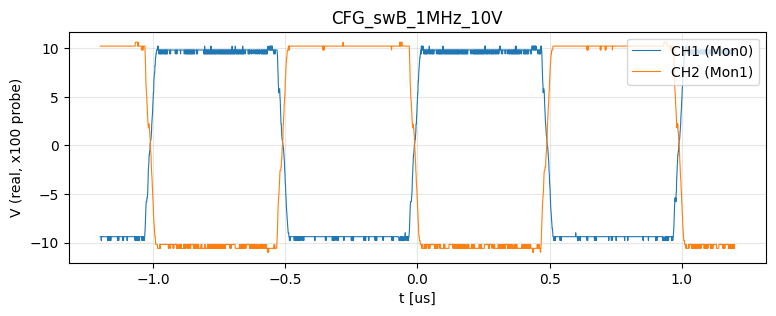

INFO    scope capture 204054_CFG_swB_1MHz_10V: {'FREQ CH1': 1000000.0, 'PER CH1': 1e-06, 'PEAK CH1': 20.0}


  FREQ CH1       = 1e+06
  PER CH1        = 1e-06
  PEAK CH1       = 20
expect: FREQ ~1.000e6 Hz | PER ~1.000e-6 s | levels at the 10 V rails


In [12]:
# One AUTO push first: baseline V/div is scaled for 350 V, the 10 V
# verify signal needs the scope to re-find it (bench, 2026-07-06).
scope_autoset()
scope_timebase_for(1e6)
res = scope_capture("CFG_swB_1MHz_10V",
                    meas=(("FREQ", "CH1"), ("PER", "CH1"), ("PEAK", "CH1")))
print("expect: FREQ ~1.000e6 Hz | PER ~1.000e-6 s | levels at the 10 V rails")
if not SIM:
    input("scope shows the complementary 1 MHz square at the 10 V rails? "
          "ENTER to continue (Ctrl+C to stop and investigate)")


In [13]:
# Campaign limits ON TOP of the config baseline (config 63's 100 mA is
# too tight for the M3/M5 ramps). Parameter moves stay function-based;
# configs are only the anchor + standby states.
# CHANGE psu2: output current limits -> 300 mA (Q1)
with psu2.thread_lock:
    psu2.set_psu0_output_current(300); psu2.set_psu1_output_current(300)
# CHANGE psu1: output current limits -> 150 mA (ion funnels)
with psu1.thread_lock:
    psu1.set_psu0_output_current(150); psu1.set_psu1_output_current(150)


def swb_set_frequency(f_khz, duty=0.5):
    """Frequency move that keeps the output symmetric. The NVM configs
    fix the width REGISTER (50 % only at their own period), so the width
    must be re-fit after every period change; width goes minimal first
    so width >= period (stuck-HIGH output, guide section 2) can never
    happen mid-move. All three moves run under swB.thread_lock (the
    live monitor polls concurrently - see the monitor cell note)."""
    with swB.thread_lock:
        # CHANGE swB: pulser 0 width -> minimum while the period moves
        swB.set_pulser_width(0, 1)
        # CHANGE swB: oscillator frequency -> f_khz
        status = swB.set_frequency_khz(f_khz)
        # CHANGE swB: pulser 0 width -> duty (default 50 %) of the new period
        swB.set_duty_cycle(0, duty)
    return status


dog.reset()
print("swB block armed:", dog.check() == [])


INFO    psu2          COM16  setting PSU0 output current to 300.000 mA
INFO    psu2          COM16  setting PSU1 output current to 300.000 mA
INFO    psu1          COM15  setting PSU0 output current to 150.000 mA
INFO    psu1          COM15  setting PSU1 output current to 150.000 mA


swB block armed: True


In [14]:
# AUTO push before the ladder (user request 2026-07-06). Harmless to
# re-run anytime the picture looks off; every M-cell re-sets the
# timebase itself via scope_timebase_for anyway.
scope_autoset()


autoset done, error queue: 0,"No error"


## M1 — frequency ladder vs `(reg+2)*10 ns`

Per rung: set frequency, note the period register, measure the true
period on the scope, fill the table in the guide. In SIM the loop just
proves the register arithmetic.

INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 99998 (~1000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 49998


      1 kHz -> reg     99998 -> calc     1.000 kHz | period 1000000 ns


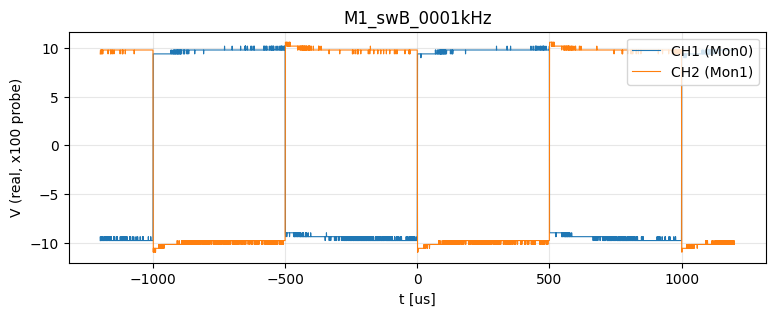

INFO    scope capture 183057_M1_swB_0001kHz: {'FREQ CH1': 1000.2, 'PER CH1': 0.0009998}


  FREQ CH1       = 1000.2
  PER CH1        = 0.0009998


INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 49998 (~2000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 24998


      2 kHz -> reg     49998 -> calc     2.000 kHz | period 500000 ns


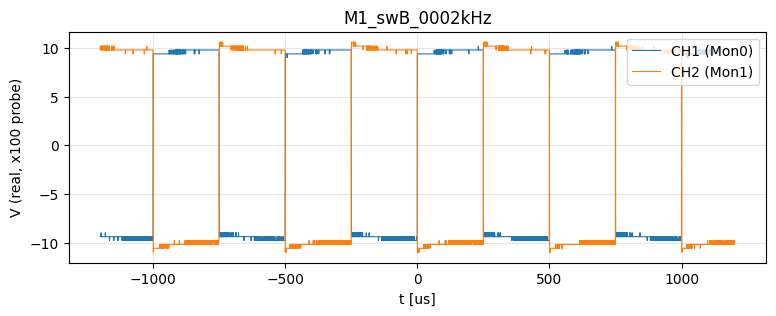

INFO    scope capture 183106_M1_swB_0002kHz: {'FREQ CH1': 2000.4, 'PER CH1': 0.0004999}


  FREQ CH1       = 2000.4
  PER CH1        = 0.0004999


INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 19998 (~5000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 9998


      5 kHz -> reg     19998 -> calc     5.000 kHz | period 200000 ns


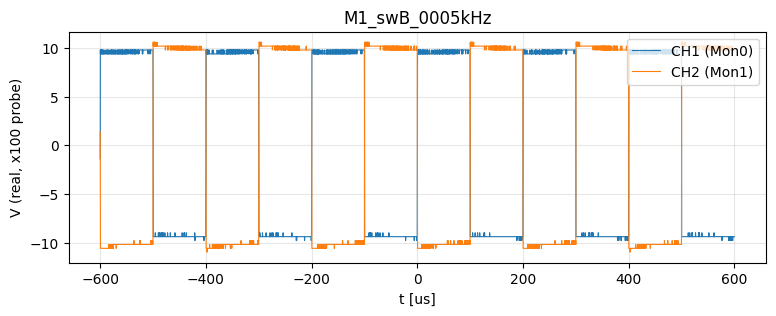

INFO    scope capture 183110_M1_swB_0005kHz: {'FREQ CH1': 5001.0, 'PER CH1': 0.00019996}


  FREQ CH1       = 5001
  PER CH1        = 0.00019996


INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 9998 (~10000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 4998


     10 kHz -> reg      9998 -> calc    10.000 kHz | period 100000 ns


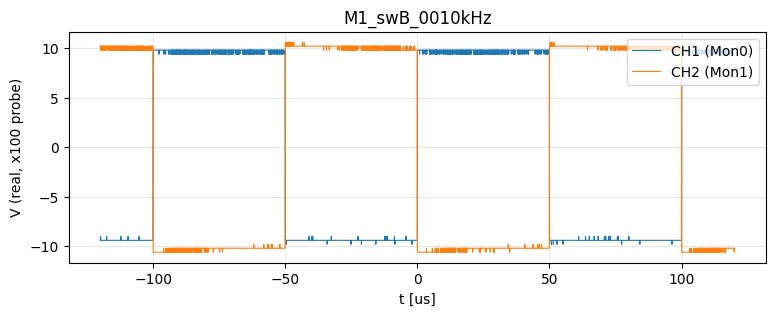

INFO    scope capture 183114_M1_swB_0010kHz: {'FREQ CH1': 10000.0, 'PER CH1': 0.0001}


  FREQ CH1       = 10000
  PER CH1        = 0.0001


INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 4998 (~20000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 2498


     20 kHz -> reg      4998 -> calc    20.000 kHz | period 50000 ns


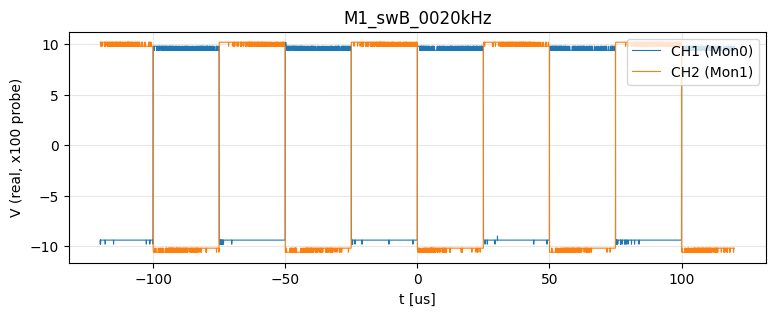

INFO    scope capture 183118_M1_swB_0020kHz: {'FREQ CH1': 20000.0, 'PER CH1': 5e-05}


  FREQ CH1       = 20000
  PER CH1        = 5e-05


WARNING psu1          COM15  watchdog: get_psu_data(0) returned -11
WARNING psu1          COM15  watchdog: get_psu_data(1) returned -13
WARNING psu4          COM18  watchdog: get_psu_data(0) returned -13
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 1998 (~50000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 998


     50 kHz -> reg      1998 -> calc    50.000 kHz | period 20000 ns


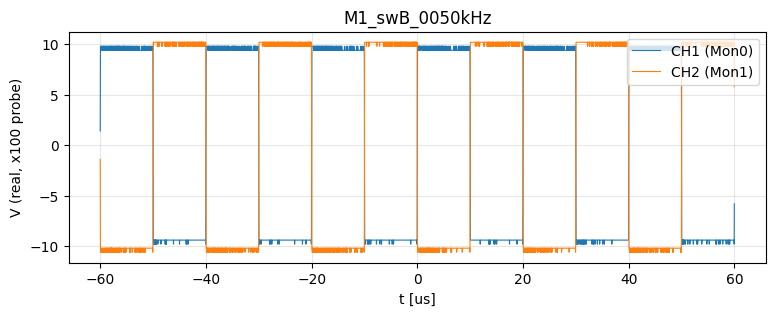

INFO    scope capture 183124_M1_swB_0050kHz: {'FREQ CH1': 50010.0, 'PER CH1': 1.9996e-05}


  FREQ CH1       = 50010
  PER CH1        = 1.9996e-05


WARNING psu1          COM15  watchdog: get_psu_data(0) returned -13
WARNING psu1          COM15  watchdog: get_psu_data(1) returned -13
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 998 (~100000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 498


    100 kHz -> reg       998 -> calc   100.000 kHz | period 10000 ns


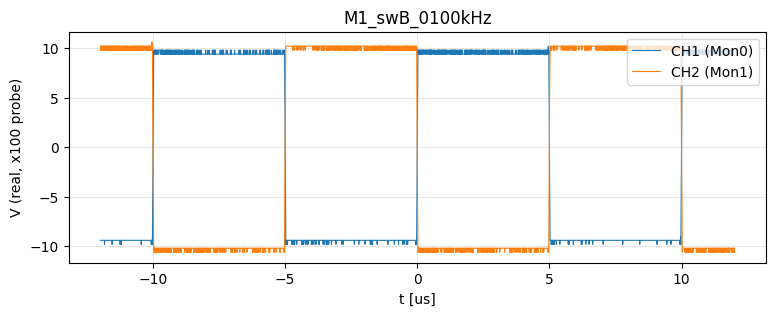

INFO    scope capture 183128_M1_swB_0100kHz: {'FREQ CH1': 100000.0, 'PER CH1': 1e-05}


  FREQ CH1       = 100000
  PER CH1        = 1e-05


WARNING psu1          COM15  watchdog: get_psu_data(0) returned -13
WARNING psu1          COM15  watchdog: get_psu_data(1) returned -13
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 498 (~200000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 248


    200 kHz -> reg       498 -> calc   200.000 kHz | period 5000 ns


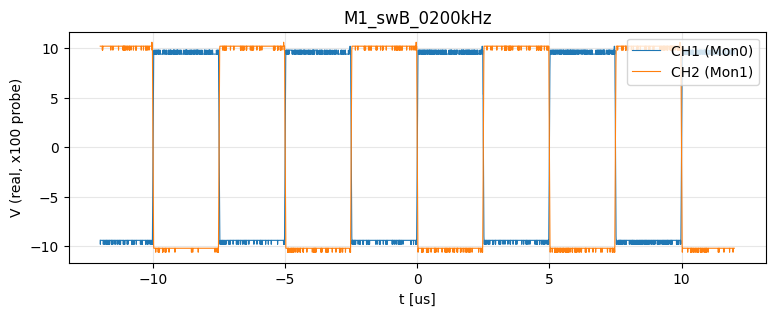

INFO    scope capture 183134_M1_swB_0200kHz: {'FREQ CH1': 200000.0, 'PER CH1': 5e-06}


  FREQ CH1       = 200000
  PER CH1        = 5e-06


WARNING psu1          COM15  watchdog: get_psu_data(0) returned -13
WARNING psu1          COM15  watchdog: get_psu_data(1) returned -13
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 198 (~500000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 98


    500 kHz -> reg       198 -> calc   500.000 kHz | period 2000 ns


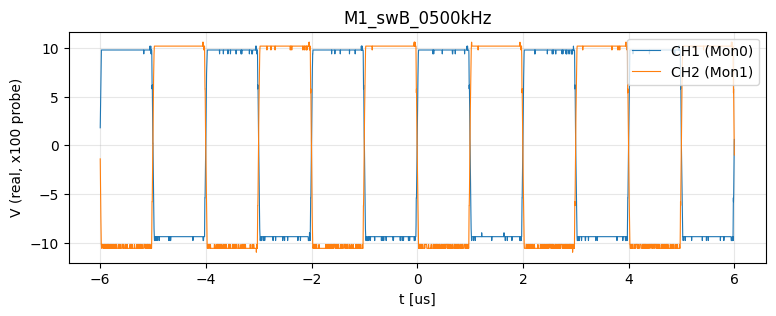

INFO    scope capture 183140_M1_swB_0500kHz: {'FREQ CH1': 500100.0, 'PER CH1': 1.9996e-06}


  FREQ CH1       = 500100
  PER CH1        = 1.9996e-06


WARNING psu1          COM15  watchdog: get_psu_data(0) returned -13
WARNING psu1          COM15  watchdog: get_psu_data(1) returned -13
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 98 (~1000000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 48


   1000 kHz -> reg        98 -> calc  1000.000 kHz | period 1000 ns


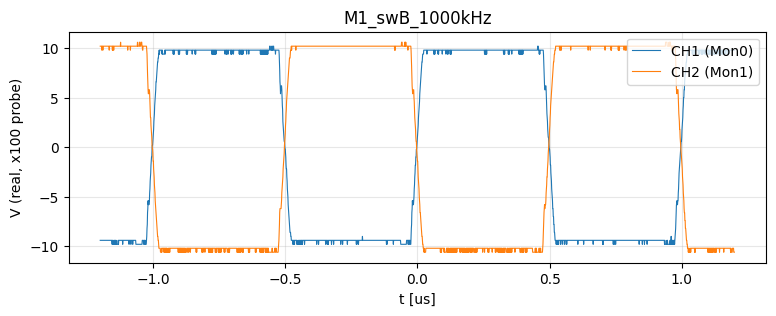

INFO    scope capture 183144_M1_swB_1000kHz: {'FREQ CH1': 1000500.0, 'PER CH1': 9.995e-07}


  FREQ CH1       = 1.0005e+06
  PER CH1        = 9.995e-07


WARNING psu1          COM15  watchdog: get_psu_data(0) returned -13
WARNING psu1          COM15  watchdog: get_psu_data(1) returned -13
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 99998 (~1000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 49998


0

In [15]:
FREQ_LADDER_KHZ = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
#FREQ_LADDER_KHZ = [1, 2, 5, 10, 20, 50]
for f_khz in FREQ_LADDER_KHZ:
    # CHANGE swB: oscillator frequency -> next ladder rung, width re-fit
    # to 50 % (config width register only fits its own period)
    swb_set_frequency(f_khz)
    with swB.thread_lock:
        status, reg = swB.get_oscillator_period()
    f_calc = swB.CLOCK / (reg + swB.OSC_OFFSET)
    print(f"{f_khz:7.0f} kHz -> reg {reg:9d} -> calc {f_calc/1e3:9.3f} kHz "
          f"| period {(reg + 2) * 10:.0f} ns")
    scope_timebase_for(f_khz * 1e3)
    scope_capture(f"M1_swB_{f_khz:04.0f}kHz",
                  meas=(("FREQ", "CH1"), ("PER", "CH1")))
    if not SIM:
        input(f"  M1 row {f_khz} kHz: f_scope/period into the guide table, "
              f"ENTER for next rung")
    dog.check()
# CHANGE swB: park at the safe 1 kHz ramp frequency, 50 % duty
swb_set_frequency(RAMP_FREQ_KHZ)


## M2 — duty cycle / pulse width + dead time

Width register: `Width_reg = duty * (Period_reg + 2) - 2`; delay minimum
= register 1 = 40 ns. Scope: verify width and the dead time between
complementary outputs at each duty point.

INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 9998 (~10000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 4998
INFO    swB           COM10  setting pulser 0 delay to 1
INFO    swB           COM10  setting pulser 0 width to 1998


duty 0.20 -> width register 1998


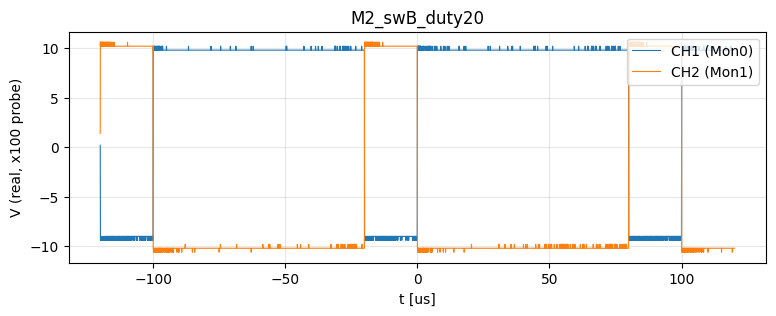

INFO    scope capture 184846_M2_swB_duty20: {'PPW CH1': 8e-05, 'PDCY CH1': 80.03201, 'DEL CH1,CH2': -2e-05}


  PPW CH1        = 8e-05
  PDCY CH1       = 80.032
  DEL CH1,CH2    = -2e-05


WARNING psu4          COM18  watchdog: get_psu_data(1) returned -11
INFO    swB           COM10  setting pulser 0 width to 3498


duty 0.35 -> width register 3498


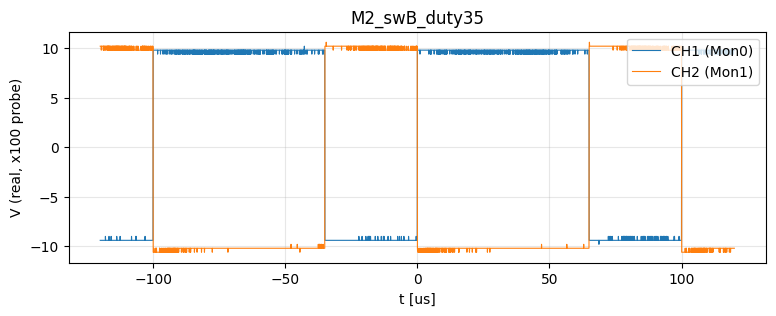

INFO    scope capture 184903_M2_swB_duty35: {'PPW CH1': 6.5e-05, 'PDCY CH1': 65.0, 'DEL CH1,CH2': -3.5e-05}


  PPW CH1        = 6.5e-05
  PDCY CH1       = 65
  DEL CH1,CH2    = -3.5e-05


WARNING psu4          COM18  watchdog: get_psu_data(0) returned -13
WARNING psu4          COM18  watchdog: get_psu_data(1) returned -13
INFO    swB           COM10  setting pulser 0 width to 4998


duty 0.50 -> width register 4998


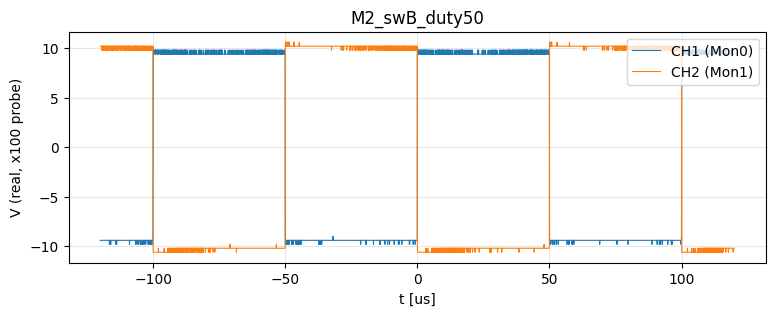

INFO    scope capture 184907_M2_swB_duty50: {'PPW CH1': 5e-05, 'PDCY CH1': 50.0, 'DEL CH1,CH2': -5e-05}


  PPW CH1        = 5e-05
  PDCY CH1       = 50
  DEL CH1,CH2    = -5e-05


WARNING psu4          COM18  watchdog: get_psu_data(0) returned -13
WARNING psu4          COM18  watchdog: get_psu_data(1) returned -13
INFO    swB           COM10  setting pulser 0 width to 6498


duty 0.65 -> width register 6498


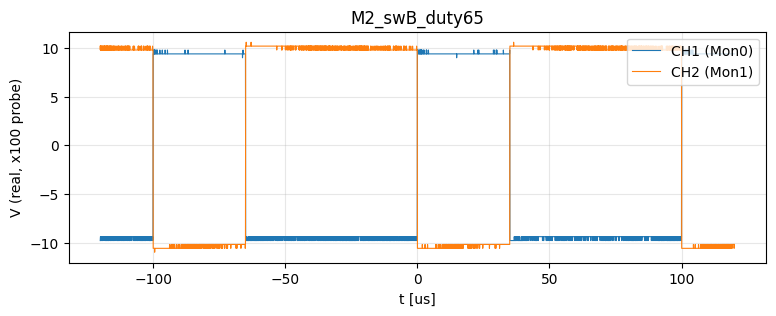

INFO    scope capture 184911_M2_swB_duty65: {'PPW CH1': 3.5e-05, 'PDCY CH1': 35.0, 'DEL CH1,CH2': 3.5e-05}


  PPW CH1        = 3.5e-05
  PDCY CH1       = 35
  DEL CH1,CH2    = 3.5e-05


WARNING psu4          COM18  watchdog: get_psu_data(0) returned -13
WARNING psu4          COM18  watchdog: get_psu_data(1) returned -13
INFO    swB           COM10  setting pulser 0 width to 7998


duty 0.80 -> width register 7998


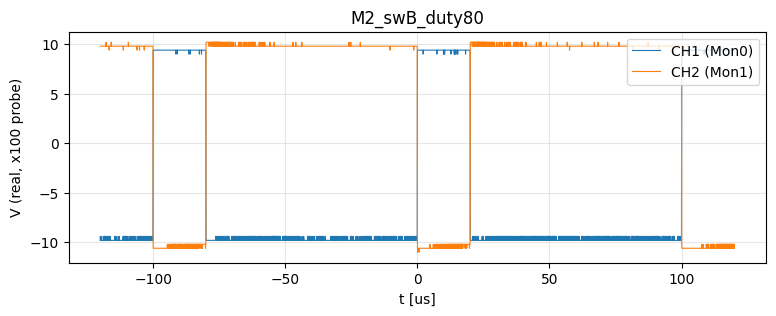

INFO    scope capture 184916_M2_swB_duty80: {'PPW CH1': 2e-05, 'PDCY CH1': 20.0, 'DEL CH1,CH2': 2e-05}


  PPW CH1        = 2e-05
  PDCY CH1       = 20
  DEL CH1,CH2    = 2e-05


WARNING psu4          COM18  watchdog: get_psu_data(0) returned -13
WARNING psu4          COM18  watchdog: get_psu_data(1) returned -13
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 99998 (~1000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 49998


0

In [24]:
DUTY_POINTS = [0.2, 0.35, 0.5, 0.65, 0.8]
# CHANGE swB: fixed 10 kHz for the duty sweep (starts at 50 %)
swb_set_frequency(10)
scope_timebase_for(10e3)
# Config 89 drives everything from pulser 0 (SwitchSym = both edges of
# PulsOut0); pulsers 1-3 stay untouched.
# CHANGE swB: pulser 0 delay -> minimum register 1 = 40 ns
# (never 0: Delay=0 with Width!=0 -> output stuck HIGH, guide section 2)
with swB.thread_lock:
    swB.set_delay_minimum(0)
for duty in DUTY_POINTS:
    # CHANGE swB: pulser 0 width -> this duty point
    with swB.thread_lock:
        swB.set_duty_cycle(0, duty)
        status, width = swB.get_pulser_width(0)
    print(f"duty {duty:4.2f} -> width register {width}")
    scope_capture(f"M2_swB_duty{int(duty * 100):02d}",
                  meas=(("PPW", "CH1"), ("PDCY", "CH1"), ("DEL", "CH1,CH2")))
    if not SIM:
        input("  M2 row: width + dead time into the guide table, "
              "ENTER for next point")
    dog.check()
# CHANGE swB: park at 1 kHz, 50 % duty
swb_set_frequency(RAMP_FREQ_KHZ)


## M3 — rise/fall vs amplitude (recipe ramp!)

Voltage ladder via `ramp_voltage_at_1khz` (watchdog after every step).
Scope: rise/fall time at each amplitude point on the loaded output.

Every capture: `scope_autoset()` (+ its built-in 1 s settle) first —
the V/div must follow the amplitude (bench 2026-07-06: 5/7 points
unmeasurable without the AUTO push).

INFO    swB           COM10  setting oscillator period to 99998 (~1000.0 Hz)
INFO    psu2          COM16  setting PSU0 output voltage to 19.998 V
INFO    psu2          COM16  setting PSU0 output voltage to 29.998 V
INFO    psu2          COM16  setting PSU0 output voltage to 39.998 V
INFO    psu2          COM16  setting PSU0 output voltage to 49.998 V
INFO    psu2          COM16  setting PSU0 output voltage to 50.000 V


amplitude point 50 V reached | readback 50.0 V  I = 0.00 mA  P = 0.00 W   (guide I column)
autoset done, error queue: 0,"No error"


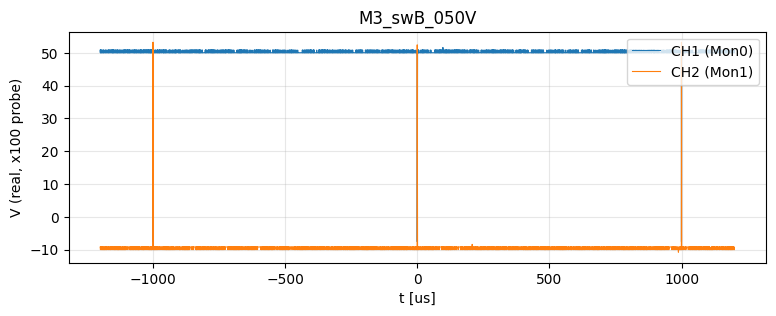

INFO    scope capture 204128_M3_swB_050V: {'RTIM CH1': 8e-07, 'FTIM CH1': 8e-07, 'POV CH1': nan, 'PEAK CH1': 59.2}


  RTIM CH1       = 8e-07
  FTIM CH1       = 8e-07
  POV CH1        = nan
  PEAK CH1       = 59.2


INFO    swB           COM10  setting oscillator period to 99998 (~1000.0 Hz)
INFO    psu2          COM16  setting PSU0 output voltage to 59.989 V
INFO    psu2          COM16  setting PSU0 output voltage to 69.989 V
INFO    psu2          COM16  setting PSU0 output voltage to 79.989 V
INFO    psu2          COM16  setting PSU0 output voltage to 89.989 V
INFO    psu2          COM16  setting PSU0 output voltage to 99.989 V
INFO    psu2          COM16  setting PSU0 output voltage to 100.000 V


amplitude point 100 V reached | readback 100.0 V  I = 0.17 mA  P = 0.02 W   (guide I column)
autoset done, error queue: 0,"No error"


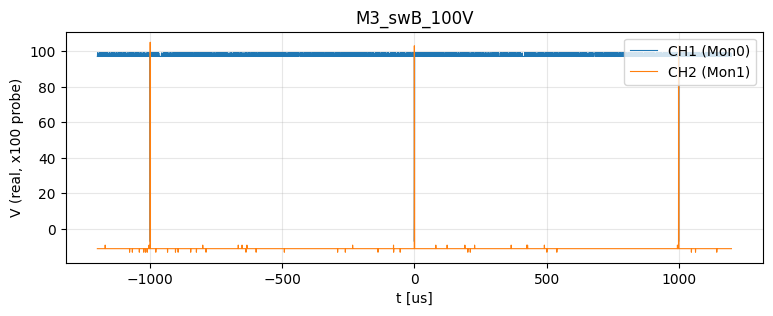

INFO    scope capture 204335_M3_swB_100V: {'RTIM CH1': 8e-07, 'FTIM CH1': 8e-07, 'POV CH1': nan, 'PEAK CH1': 106.0}


  RTIM CH1       = 8e-07
  FTIM CH1       = 8e-07
  POV CH1        = nan
  PEAK CH1       = 106


INFO    swB           COM10  setting oscillator period to 99998 (~1000.0 Hz)
INFO    psu2          COM16  setting PSU0 output voltage to 110.002 V
INFO    psu2          COM16  setting PSU0 output voltage to 120.002 V
INFO    psu2          COM16  setting PSU0 output voltage to 130.002 V
INFO    psu2          COM16  setting PSU0 output voltage to 140.002 V
INFO    psu2          COM16  setting PSU0 output voltage to 150.000 V


amplitude point 150 V reached | readback 150.0 V  I = 0.34 mA  P = 0.05 W   (guide I column)
autoset done, error queue: 0,"No error"


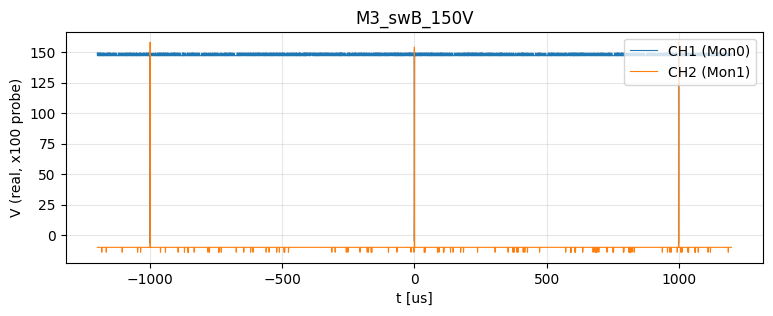

INFO    scope capture 204432_M3_swB_150V: {'RTIM CH1': 8e-07, 'FTIM CH1': 8e-07, 'POV CH1': nan, 'PEAK CH1': 156.0}


  RTIM CH1       = 8e-07
  FTIM CH1       = 8e-07
  POV CH1        = nan
  PEAK CH1       = 156


INFO    swB           COM10  setting oscillator period to 99998 (~1000.0 Hz)
INFO    psu2          COM16  setting PSU0 output voltage to 159.991 V
INFO    psu2          COM16  setting PSU0 output voltage to 169.991 V
INFO    psu2          COM16  setting PSU0 output voltage to 179.991 V
INFO    psu2          COM16  setting PSU0 output voltage to 189.991 V
INFO    psu2          COM16  setting PSU0 output voltage to 199.991 V
INFO    psu2          COM16  setting PSU0 output voltage to 200.000 V


amplitude point 200 V reached | readback 200.0 V  I = 0.51 mA  P = 0.10 W   (guide I column)
autoset done, error queue: 0,"No error"


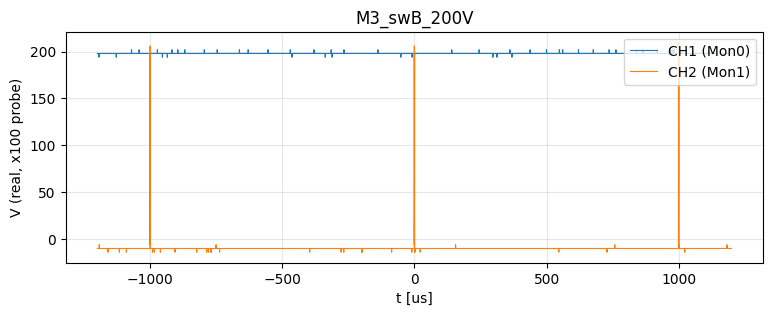

INFO    scope capture 204454_M3_swB_200V: {'RTIM CH1': 8e-07, 'FTIM CH1': 8e-07, 'POV CH1': nan, 'PEAK CH1': 208.0}


  RTIM CH1       = 8e-07
  FTIM CH1       = 8e-07
  POV CH1        = nan
  PEAK CH1       = 208


INFO    swB           COM10  setting oscillator period to 99998 (~1000.0 Hz)
INFO    psu2          COM16  setting PSU0 output voltage to 210.003 V
INFO    psu2          COM16  setting PSU0 output voltage to 220.003 V
INFO    psu2          COM16  setting PSU0 output voltage to 230.003 V
INFO    psu2          COM16  setting PSU0 output voltage to 240.003 V
INFO    psu2          COM16  setting PSU0 output voltage to 250.000 V


amplitude point 250 V reached | readback 250.0 V  I = 0.69 mA  P = 0.17 W   (guide I column)
autoset done, error queue: 0,"No error"


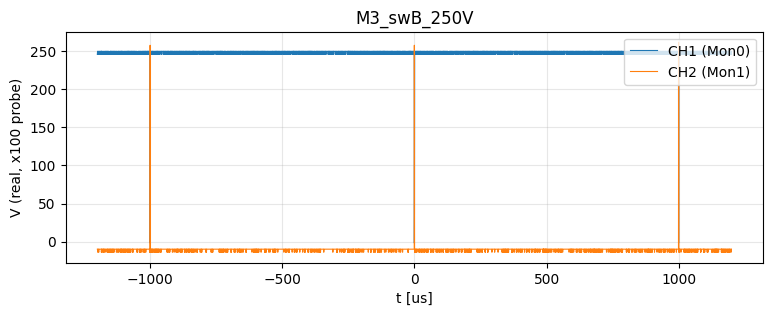

INFO    scope capture 204513_M3_swB_250V: {'RTIM CH1': 8e-07, 'FTIM CH1': 8e-07, 'POV CH1': nan, 'PEAK CH1': 252.0}


  RTIM CH1       = 8e-07
  FTIM CH1       = 8e-07
  POV CH1        = nan
  PEAK CH1       = 252


INFO    swB           COM10  setting oscillator period to 99998 (~1000.0 Hz)
INFO    psu2          COM16  setting PSU0 output voltage to 259.992 V
INFO    psu2          COM16  setting PSU0 output voltage to 269.992 V
INFO    psu2          COM16  setting PSU0 output voltage to 279.992 V
INFO    psu2          COM16  setting PSU0 output voltage to 289.992 V
INFO    psu2          COM16  setting PSU0 output voltage to 299.992 V
INFO    psu2          COM16  setting PSU0 output voltage to 300.000 V


amplitude point 300 V reached | readback 300.0 V  I = 0.85 mA  P = 0.26 W   (guide I column)
autoset done, error queue: 0,"No error"


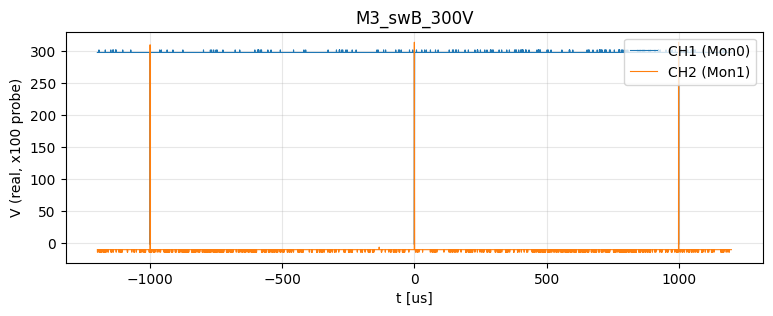

INFO    scope capture 204542_M3_swB_300V: {'RTIM CH1': 8e-07, 'FTIM CH1': 8e-07, 'POV CH1': nan, 'PEAK CH1': 304.0}


  RTIM CH1       = 8e-07
  FTIM CH1       = 8e-07
  POV CH1        = nan
  PEAK CH1       = 304


INFO    swB           COM10  setting oscillator period to 99998 (~1000.0 Hz)
INFO    psu2          COM16  setting PSU0 output voltage to 310.005 V
INFO    psu2          COM16  setting PSU0 output voltage to 320.005 V
INFO    psu2          COM16  setting PSU0 output voltage to 330.005 V
INFO    psu2          COM16  setting PSU0 output voltage to 340.005 V
INFO    psu2          COM16  setting PSU0 output voltage to 350.000 V


amplitude point 350 V reached | readback 350.0 V  I = 1.03 mA  P = 0.36 W   (guide I column)
autoset done, error queue: 0,"No error"


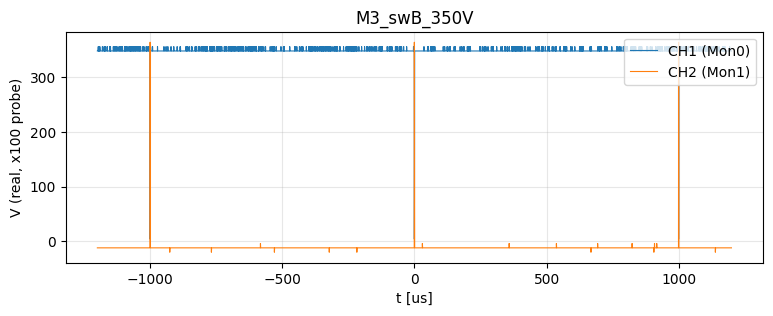

INFO    scope capture 204601_M3_swB_350V: {'RTIM CH1': 8e-07, 'FTIM CH1': 8e-07, 'POV CH1': nan, 'PEAK CH1': 352.0}


  RTIM CH1       = 8e-07
  FTIM CH1       = 8e-07
  POV CH1        = nan
  PEAK CH1       = 352
final setpoint: 350 V


In [15]:
V_POINTS = [50.0, 100.0, 150.0, 200.0, 250.0, 300.0, 350.0]
DWELL_S = 0.05 if SIM else 2.0
scope_timebase_for(1e3)   # ramp runs at 1 kHz
v_reached = 0.0
try:
    for v in V_POINTS:
        # CHANGE psu2 ch0 + swB: recipe ramp - 1 kHz forced, voltage in
        # 10 V steps up to this amplitude point, watchdog after every step
        v_reached = ramp_voltage_at_1khz(
            swB, psu2, psu2.PSU_POS, v, step_v=10.0, dwell_s=DWELL_S,
            watchdog=dog)
        with psu2.thread_lock:
            _, v_now, i_a, _ = psu2.get_psu_data(psu2.PSU_POS)
        print(f"amplitude point {v_reached:.0f} V reached | "
              f"readback {v_now:.1f} V  I = {i_a * 1000.0:.2f} mA  "
              f"P = {v_now * i_a:.2f} W   (guide I column)")
        # V/div must follow the amplitude: AUTO + settle before every
        # shot (bench 2026-07-06: 5/7 points unmeasurable without it;
        # the ramp's final dwell already let the switch settle).
        scope_autoset()
        scope_capture(f"M3_swB_{v_reached:03.0f}V",
                      meas=(("RTIM", "CH1"), ("FTIM", "CH1"),
                            ("POV", "CH1"), ("PEAK", "CH1")))
        if not SIM:
            input("  M3 row: rise/fall/overshoot + I into the guide table, "
                  "ENTER for next")
except WatchdogBreach as e:
    print(f"RAMP HALTED: {e}")
print(f"final setpoint: {v_reached:.0f} V")

## M4 — channel skew (2 probes)

Both probes on the complementary pair; measure edge-to-edge skew at 1 kHz
and at 100 kHz. Record in the guide table; no code beyond configuration.

INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 99998 (~1000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 49998


skew point 1: 1 kHz (probes on out0/out1)


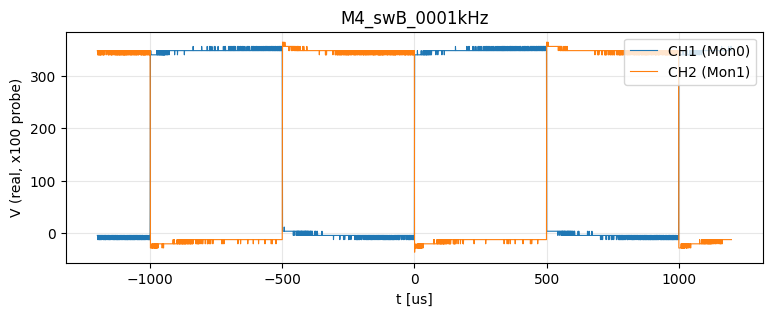

INFO    scope capture 192016_M4_swB_0001kHz: {'DEL CH1,CH2': 0.0004996, 'PHAS CH1,CH2': 179.928}


  DEL CH1,CH2    = 0.0004996
  PHAS CH1,CH2   = 179.928


INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 998 (~100000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 498


skew point 2: 100 kHz


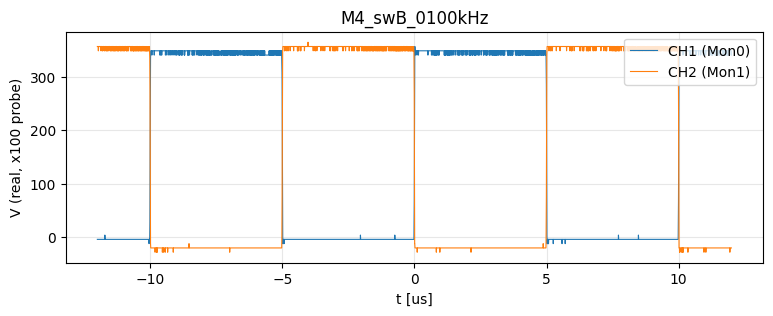

INFO    scope capture 192020_M4_swB_0100kHz: {'DEL CH1,CH2': -5e-06, 'PHAS CH1,CH2': -180.0}


  DEL CH1,CH2    = -5e-06
  PHAS CH1,CH2   = -180


INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 99998 (~1000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 49998
WARNING psu1          COM15  watchdog: get_psu_data(0) returned -13
WARNING psu1          COM15  watchdog: get_psu_data(1) returned -13


[]

In [51]:
# CHANGE swB: frequency -> 1 kHz, 50 % duty (skew point 1)
swb_set_frequency(RAMP_FREQ_KHZ)
scope_timebase_for(1e3)
print("skew point 1: 1 kHz (probes on out0/out1)")
scope_capture("M4_swB_0001kHz",
              meas=(("DEL", "CH1,CH2"), ("PHAS", "CH1,CH2")))
if not SIM:
    input("  M4 row: skew at 1 kHz into the guide table, ENTER to continue")
# CHANGE swB: frequency -> 100 kHz, 50 % duty (skew point 2)
swb_set_frequency(100)
scope_timebase_for(100e3)
print("skew point 2: 100 kHz")
scope_capture("M4_swB_0100kHz",
              meas=(("DEL", "CH1,CH2"), ("PHAS", "CH1,CH2")))
if not SIM:
    input("  M4 row: skew at 100 kHz into the guide table, ENTER to continue")
# CHANGE swB: park at 1 kHz, 50 % duty
swb_set_frequency(RAMP_FREQ_KHZ)
dog.check()


In [53]:
# Manual RX-buffer flush - clears a poisoned wire after crossed frames
# (-13 storm, see the monitor cell note). The watchdog now purges +
# retries on its own; keep this cell for by-hand recovery.
for name, p in (("psu1", psu1), ("psu2", psu2), ("psu3", psu3), ("psu4", psu4)):
    with p.thread_lock:
        status = p.purge()
    print(f"{name} purge -> status {status}")

0

In [54]:
# Spot check ch0 of every supply: (status, V, I [A], dropout V).
for name, p in (("psu1", psu1), ("psu2", psu2), ("psu3", psu3), ("psu4", psu4)):
    with p.thread_lock:
        print(name, p.get_psu0_data())

(0, 0.117, 0.0, 494.08)
(0, 350.03, 0.003354, 138.949)
(0, 0.488, 0.0, 243.743)
(0, 0.485, 0.0, 242.718)


## M5 — current draw vs frequency (envelope mapping)

Full voltage from M3, then the doubling ladder with the watchdog: the
point of this matrix row is to approach (never cross) 300 mA / 100 W
and map where the envelope closes. The watchdog's step-down IS the
data point.

Per step (day-2 evening fix, 2026-07-06): psu2 ch0 **V / I / P
printed** and an **AUTO'd capture saved** — fill the guide rows from
the cell output afterwards. Deliberately no ENTER pauses: the switch
should not sit at full V·f longer than needed.

INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 49998 (~2000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 24998


       2 kHz | psu2 ch0:  350.0 V  I =    3.62 mA  P =   1.27 W
autoset done, error queue: 0,"No error"


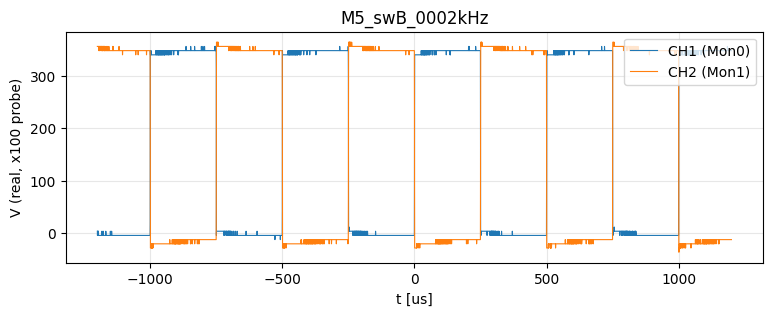

INFO    scope capture 204921_M5_swB_0002kHz: {'FREQ CH1': 2000.4, 'PEAK CH1': 368.0}
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 24998 (~4000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 12498


  FREQ CH1       = 2000.4
  PEAK CH1       = 368
       4 kHz | psu2 ch0:  350.0 V  I =    4.17 mA  P =   1.46 W
autoset done, error queue: 0,"No error"


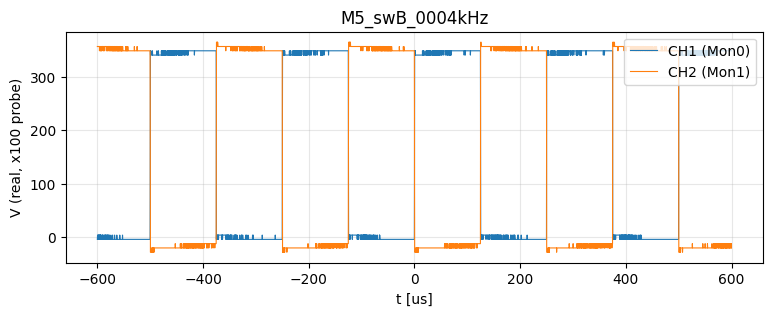

INFO    scope capture 204927_M5_swB_0004kHz: {'FREQ CH1': 4000.8, 'PEAK CH1': 352.0}
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 12498 (~8000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 6248


  FREQ CH1       = 4000.8
  PEAK CH1       = 352
       8 kHz | psu2 ch0:  350.0 V  I =    5.28 mA  P =   1.85 W
autoset done, error queue: 0,"No error"


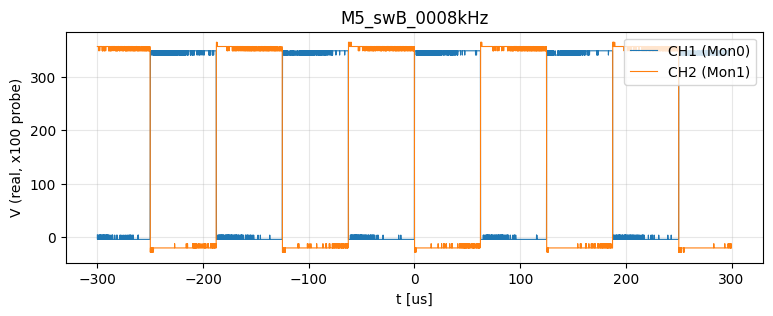

INFO    scope capture 204933_M5_swB_0008kHz: {'FREQ CH1': 8001.6, 'PEAK CH1': 352.0}
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 6248 (~16000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 3123


  FREQ CH1       = 8001.6
  PEAK CH1       = 352
      16 kHz | psu2 ch0:  350.0 V  I =    7.46 mA  P =   2.61 W
autoset done, error queue: 0,"No error"


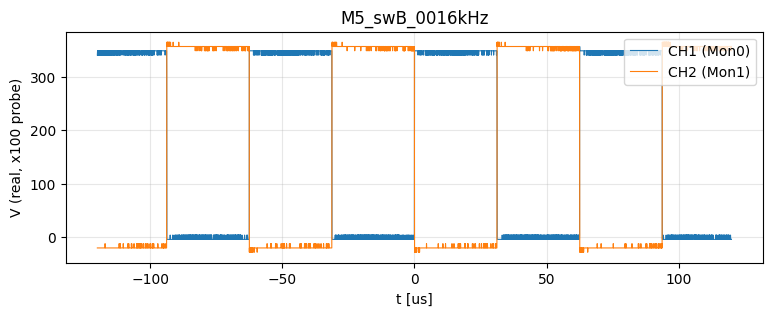

INFO    scope capture 204939_M5_swB_0016kHz: {'FREQ CH1': 16001.71, 'PEAK CH1': 360.0}
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 3123 (~32000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 1560


  FREQ CH1       = 16001.7
  PEAK CH1       = 360
      32 kHz | psu2 ch0:  350.0 V  I =   11.83 mA  P =   4.14 W
autoset done, error queue: 0,"No error"


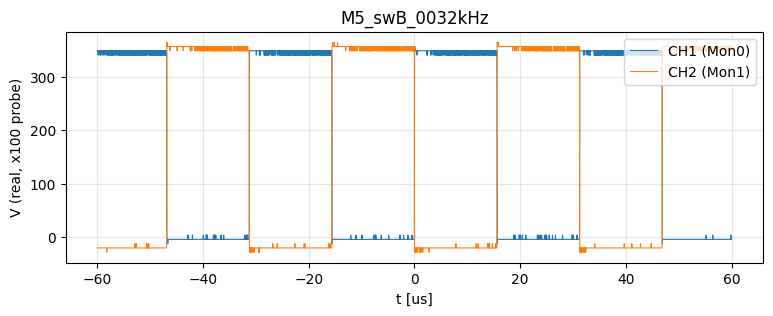

INFO    scope capture 204945_M5_swB_0032kHz: {'FREQ CH1': 32003.41, 'PEAK CH1': 368.0}
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 1560 (~64020.5 Hz)
INFO    swB           COM10  setting pulser 0 width to 779


  FREQ CH1       = 32003.4
  PEAK CH1       = 368
      64 kHz | psu2 ch0:  350.0 V  I =   20.58 mA  P =   7.20 W
autoset done, error queue: 0,"No error"


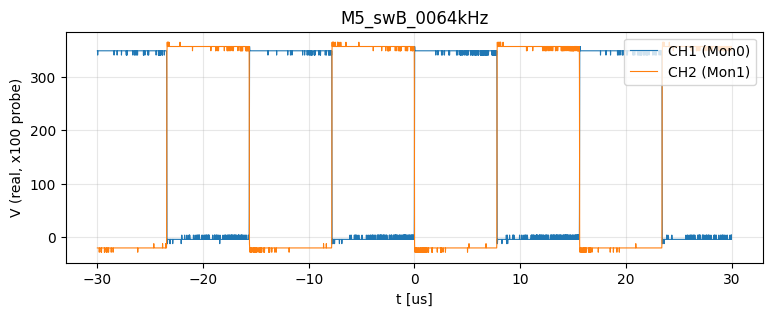

INFO    scope capture 204951_M5_swB_0064kHz: {'FREQ CH1': 64020.49, 'PEAK CH1': 368.0}
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 779 (~128041.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 388


  FREQ CH1       = 64020.5
  PEAK CH1       = 368
     128 kHz | psu2 ch0:  350.0 V  I =   38.06 mA  P =  13.32 W
autoset done, error queue: 0,"No error"


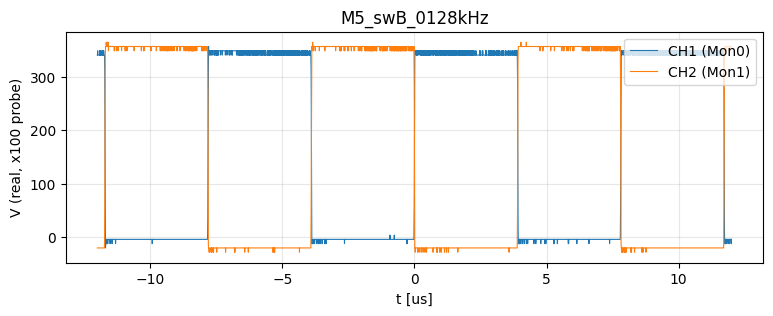

INFO    scope capture 204957_M5_swB_0128kHz: {'FREQ CH1': 128030.0, 'PEAK CH1': 376.0}
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 389 (~255754.5 Hz)
INFO    swB           COM10  setting pulser 0 width to 194


  FREQ CH1       = 128030
  PEAK CH1       = 376
     256 kHz | psu2 ch0:  350.0 V  I =   73.03 mA  P =  25.56 W
autoset done, error queue: 0,"No error"


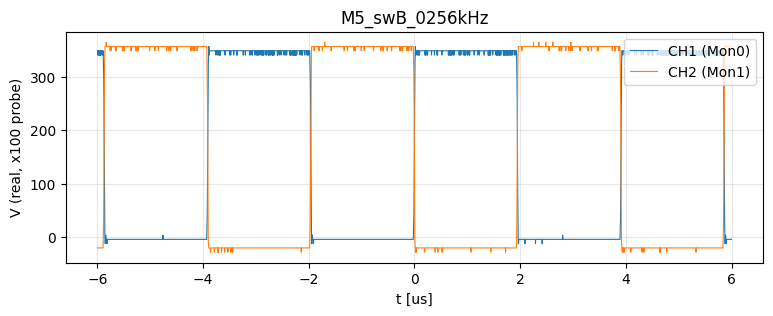

INFO    scope capture 205003_M5_swB_0256kHz: {'FREQ CH1': 255754.5, 'PEAK CH1': 368.0}
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 193 (~512820.5 Hz)
INFO    swB           COM10  setting pulser 0 width to 96


  FREQ CH1       = 255754
  PEAK CH1       = 368
     512 kHz | psu2 ch0:  350.0 V  I =  144.07 mA  P =  50.43 W
autoset done, error queue: 0,"No error"


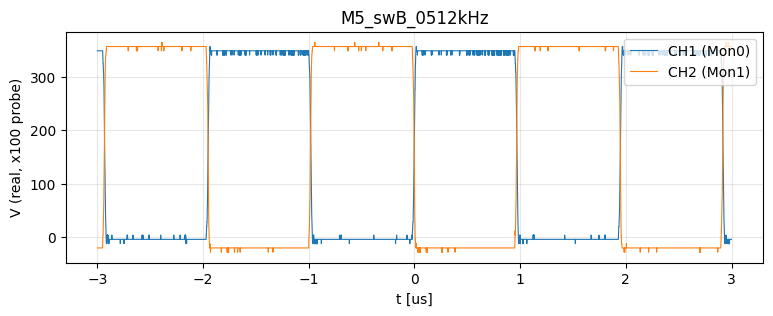

INFO    scope capture 205009_M5_swB_0512kHz: {'FREQ CH1': 512820.5, 'PEAK CH1': 368.0}
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 98 (~1000000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 48


  FREQ CH1       = 512820
  PEAK CH1       = 368


WARNING psu3          COM17  watchdog: get_psu_data(0) returned -11 - purging + retrying


    1000 kHz | psu2 ch0:  350.0 V  I =  282.18 mA  P =  98.77 W
autoset done, error queue: 0,"No error"


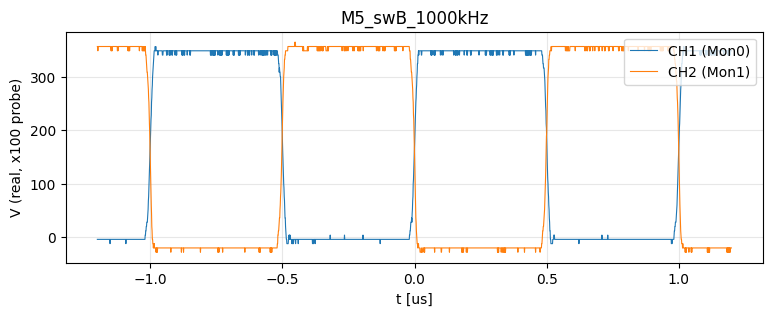

INFO    scope capture 205015_M5_swB_1000kHz: {'FREQ CH1': 1000000.0, 'PEAK CH1': 368.0}
INFO    swB           COM10  setting pulser 0 width to 1
INFO    swB           COM10  setting oscillator period to 99998 (~1000.0 Hz)
INFO    swB           COM10  setting pulser 0 width to 49998


  FREQ CH1       = 1e+06
  PEAK CH1       = 368
envelope open up to 1000 kHz at this amplitude


In [16]:
# campaign.ramp_frequency has no width re-fit -> duty would drift with
# frequency; the swB envelope loop therefore steps explicitly through
# the same doubling ladder with swb_set_frequency + watchdog per step.
# Per step (guide 4A-M5 columns): I + P printed, AUTO + capture saved.
# No ENTER pauses - fill the table from the cell output afterwards.
ENVELOPE_TARGET_KHZ = 1000.0
steps, f = [], RAMP_FREQ_KHZ
while f < ENVELOPE_TARGET_KHZ:
    f = min(f * 2.0, ENVELOPE_TARGET_KHZ)
    steps.append(f)
f_now = RAMP_FREQ_KHZ
try:
    for f in steps:
        # CHANGE swB: frequency -> f (width re-fit to 50 %), watchdog
        # after every step (its step-down IS the data point)
        swb_set_frequency(f)
        f_now = f
        time.sleep(DWELL_S)
        breaches = dog.check()
        if breaches:
            b = breaches[0]
            print(f"{f_now:8g} kHz | WATCHDOG: {b['current_ma']:.1f} mA / "
                  f"{b['power_w']:.1f} W at breach (setpoint stepped down)")
        else:
            with psu2.thread_lock:
                _, v_now, i_a, _ = psu2.get_psu_data(psu2.PSU_POS)
            print(f"{f_now:8g} kHz | psu2 ch0: {v_now:6.1f} V  "
                  f"I = {i_a * 1000.0:7.2f} mA  P = {v_now * i_a:6.2f} W")
        scope_autoset()
        scope_capture(f"M5_swB_{f_now:04.0f}kHz",
                      meas=(("FREQ", "CH1"), ("PEAK", "CH1")))
        if breaches:
            raise WatchdogBreach(
                f"frequency ramp stopped at {f_now:g} kHz (watchdog breach)")
    print(f"envelope open up to {f_now:g} kHz at this amplitude")
except WatchdogBreach as e:
    print(f"ENVELOPE EDGE: {e}")
finally:
    # CHANGE swB: park at 1 kHz, 50 % duty
    swb_set_frequency(RAMP_FREQ_KHZ)

In [20]:
# swB block teardown -> STANDBY CONFIGS (user rule: standby configs back
# after every finished test). PSUs first, then the switch — python 0 =
# [Configuration1]: DeviceEnable=N, outputs off, 0 V.
# CHANGE psu1+psu2: outputs -> 0 V, then NVM standby config 0
for name, p in (("psu1", psu1), ("psu2", psu2)):
    with p.thread_lock:
        p.purge()   # flush a possibly-poisoned RX buffer BEFORE commanding
        p.set_psu_output_voltage(p.PSU_POS, 0.0)
        p.set_psu_output_voltage(p.PSU_NEG, 0.0)
        status = p.load_current_config(STANDBY_CONFIG)
    print(f"{name} -> standby config (status {status})")
# CHANGE swB: NVM standby config 0 (after the PSUs)
with swB.thread_lock:
    swB.purge()
    status = swB.load_current_config(STANDBY_CONFIG)
print(f"swB  -> standby config (status {status})")
print("swB block parked")


INFO    psu1          COM15  setting PSU0 output voltage to 0.000 V
INFO    psu1          COM15  setting PSU1 output voltage to 0.000 V
INFO    psu1          COM15  loading config slot 0
INFO    psu2          COM16  setting PSU0 output voltage to 0.000 V
INFO    psu2          COM16  setting PSU1 output voltage to 0.000 V
INFO    psu2          COM16  loading config slot 0
INFO    swB           COM10  loading config slot 0


psu1 -> standby config (status 0)
psu2 -> standby config (status 0)
swB  -> standby config (status 0)
swB block parked


# swA session (SWHR — high resolution)

**Correction (2026-07-06):** `config_swA.cfg` DOES carry a SwitchSym
ladder — the RF-ladder clone from the P6.8 plan is **not needed**.
Python indices (file slot − 1): 269=1 kHz zero-delay, 270=1 kHz default
delay, 272=10 kHz, 273=100 kHz, 274=250 kHz, 275=400 kHz, 276=500 kHz,
**277=1 MHz** (023-proven baseline), 279–288=HF 0.84–10 MHz.

Bring-up mirrors swB: swA config first, then psu3/psu4 config 63,
verify on the scope, then function-based moves. Fine-delay sweep:
coarse 5 ns steps, fine 11 ps steps (`SWITCH_DELAY_FINE_SCALE`).


INFO    swA           COM9   loading config slot 277
INFO    psu3          COM17  loading config slot 63
INFO    psu4          COM18  loading config slot 63


swA   config 277 -> status 0
psu3  config 63 -> status 0
psu4  config 63 -> status 0
swA   enabled=True  osc0 reg=98 -> 1.000 MHz (expect 1.000)
psu3  ch0:  10.02 V   29.91 mA  out_en=True
psu3  ch1:  10.03 V   30.01 mA  out_en=True
psu4  ch0:  10.02 V   29.95 mA  out_en=True
psu4  ch1:  10.02 V   29.95 mA  out_en=True
autoset done, error queue: 0,"No error"


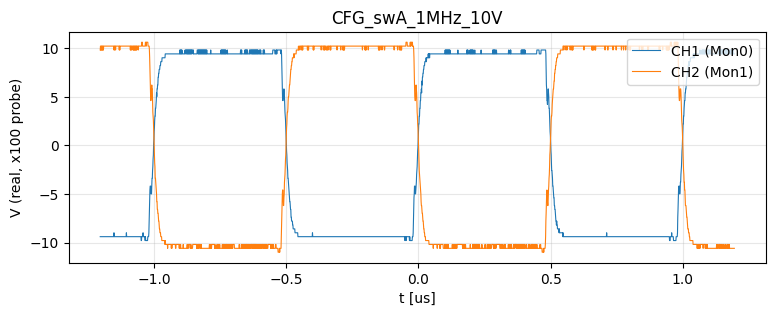

INFO    scope capture 205703_CFG_swA_1MHz_10V: {'FREQ CH1': 999500.2, 'PER CH1': 1.0005e-06, 'PEAK CH1': 19.6}


  FREQ CH1       = 999500
  PER CH1        = 1.0005e-06
  PEAK CH1       = 19.6


INFO    psu3          COM17  setting PSU0 output current to 300.000 mA
INFO    psu3          COM17  setting PSU1 output current to 300.000 mA
INFO    psu4          COM18  setting PSU0 output current to 150.000 mA
INFO    psu4          COM18  setting PSU1 output current to 150.000 mA


swA block armed: True


In [22]:
# swA block bring-up — NVM configs (swA FIRST, then psu3/psu4; 023 order).
SWA_CONFIG = 277   # [Configuration278] 1 MHz SwitchSym default delay (023-proven)

# CHANGE swA: NVM config -> 277 (1 MHz SwitchSym, default delay)
with swA.thread_lock:
    status = swA.load_current_config(SWA_CONFIG)
print(f"swA   config {SWA_CONFIG} -> status {status}")
# CHANGE psu3+psu4: NVM config -> 63 (10 V / 100 mA, outputs + device ON)
for name, p in (("psu3", psu3), ("psu4", psu4)):
    with p.thread_lock:
        status = p.load_current_config(PSU_CONFIG)
    print(f"{name}  config {PSU_CONFIG} -> status {status}")

# Readback (SIM: config load is a no-op on the sim state — expect False/0).
with swA.thread_lock:
    _, sw_en = swA.get_device_enable()
    _, reg = swA.get_oscillator_period(0)
f_mhz = swA.DEF_CLOCK / (reg + swA.OSC_OFFSET) / 1e6 if reg > 0 else 0.0
print(f"swA   enabled={sw_en}  osc0 reg={reg} -> {f_mhz:.3f} MHz (expect 1.000)")
for name, p in (("psu3", psu3), ("psu4", psu4)):
    with p.thread_lock:
        _, en0, en1 = p.get_psu_enable()
        readings = [p.get_psu_data(ch) for ch in (p.PSU_POS, p.PSU_NEG)]
    for ch, (_, v, i_a, _) in zip((p.PSU_POS, p.PSU_NEG), readings):
        print(f"{name}  ch{ch}: {v:6.2f} V  {i_a * 1000:6.2f} mA  "
              f"out_en={(en0, en1)[ch]}")

# Scope verify BEFORE any parameter move (same criteria as the swB
# block); AUTO push first - see the swB verify cell.
scope_autoset()
scope_timebase_for(1e6)
scope_capture("CFG_swA_1MHz_10V",
              meas=(("FREQ", "CH1"), ("PER", "CH1"), ("PEAK", "CH1")))
if not SIM:
    input("scope shows the complementary 1 MHz square at the 10 V rails? "
          "ENTER to continue (Ctrl+C to stop and investigate)")

# Campaign limits (Q2 = psu3 at 300 mA; Q3/4 = psu4 at 150 mA per 023).
# CHANGE psu3: output current limits -> 300 mA (Q2)
with psu3.thread_lock:
    psu3.set_psu0_output_current(300); psu3.set_psu1_output_current(300)
# CHANGE psu4: output current limits -> 150 mA (Q3/4)
with psu4.thread_lock:
    psu4.set_psu0_output_current(150); psu4.set_psu1_output_current(150)
dog.reset()
print("swA block armed:", dog.check() == [])


In [23]:
# RF-ladder clone scaffold — OBSOLETE (2026-07-06): config_swA.cfg
# already carries the SwitchSym ladder (python 269-277 + HF 279-288).
# Kept only in case extra slots are ever wanted; leave WRITE_LADDER=False.
WRITE_LADDER = False
if WRITE_LADDER:
    LADDER = {40: 1, 50: 10, 60: 50, 70: 100, 80: 500, 90: 1000}  # slot: kHz
    for slot, f_khz in LADDER.items():
        # CHANGE swA: oscillator 0 -> ladder frequency, then NVM save to
        # slot (NVM busy = CTS deasserted - wait for readiness between saves)
        swA.set_frequency_khz(0, f_khz)
        swA.save_current_config(slot)
        status, reg = swA.get_oscillator_period(0)
        print(f"slot {slot:3d} <- {f_khz:5d} kHz (osc0 reg {reg})")
    print("ladder written - verify with load_current_config at the bench")
else:
    print("skipped - swA SwitchSym ladder already in NVM (python 269-277)")


skipped - swA SwitchSym ladder already in NVM (python 269-277)


## M3-HR — fine-delay sweep -> edge placement

Rise fine delay 0 -> 0x1FF in steps; scope: edge shift must track
11 ps/LSB. Same for fall delay on the second probe.

INFO    swA           COM9   setting oscillator 0 period to 99998 (~1000.0 Hz)
INFO    swA           COM9   setting switch 0 fine rise delay to 0


fine 0x000 -> expected edge shift       0 ps


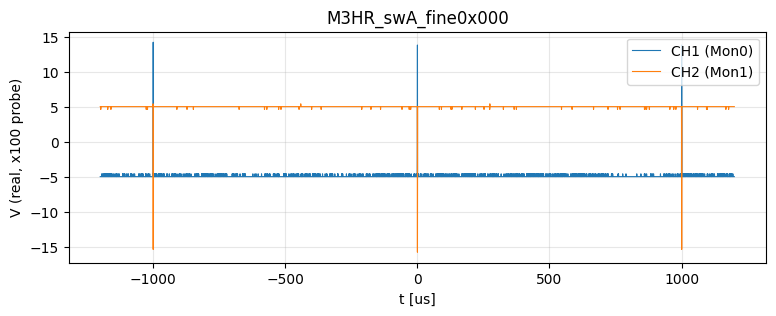

INFO    scope capture 205835_M3HR_swA_fine0x000: {'DEL CH1,CH2': 4e-07}


  DEL CH1,CH2    = 4e-07


WARNING psu1          COM15  watchdog: get_psu_data(0) returned -11 - purging + retrying
WARNING psu1          COM15  watchdog: get_psu_data(1) returned -11 - purging + retrying
INFO    swA           COM9   setting switch 0 fine rise delay to 128


fine 0x080 -> expected edge shift    1408 ps


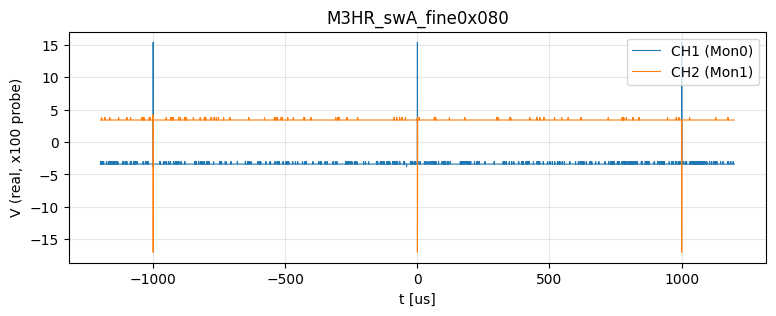

INFO    scope capture 205845_M3HR_swA_fine0x080: {'DEL CH1,CH2': 4e-07}


  DEL CH1,CH2    = 4e-07


INFO    swA           COM9   setting switch 0 fine rise delay to 256


fine 0x100 -> expected edge shift    2816 ps


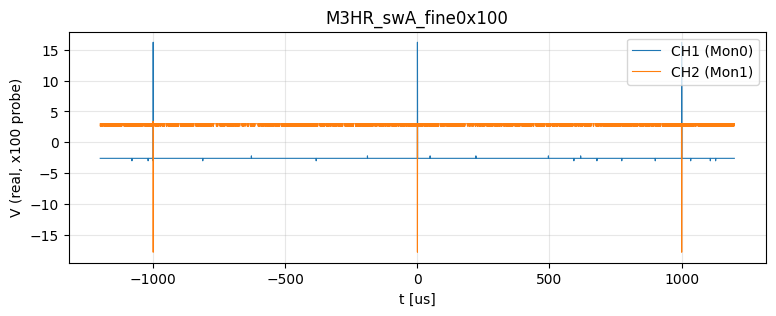

INFO    scope capture 205853_M3HR_swA_fine0x100: {'DEL CH1,CH2': 4e-07}


  DEL CH1,CH2    = 4e-07


WARNING psu3          COM17  watchdog: get_psu_data(0) returned -13 - purging + retrying
INFO    swA           COM9   setting switch 0 fine rise delay to 384


fine 0x180 -> expected edge shift    4224 ps


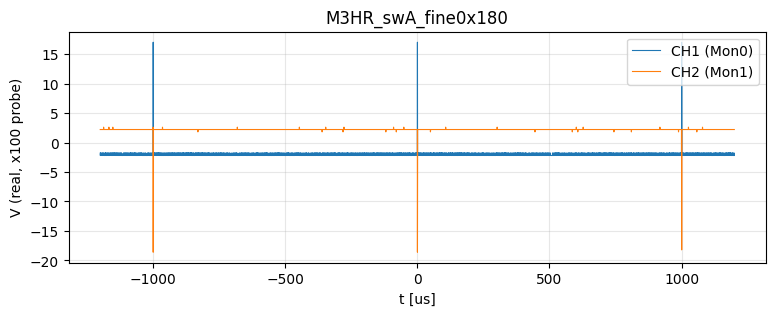

INFO    scope capture 205902_M3HR_swA_fine0x180: {'DEL CH1,CH2': 4e-07}


  DEL CH1,CH2    = 4e-07


INFO    swA           COM9   setting switch 0 fine rise delay to 511


fine 0x1FF -> expected edge shift    5621 ps


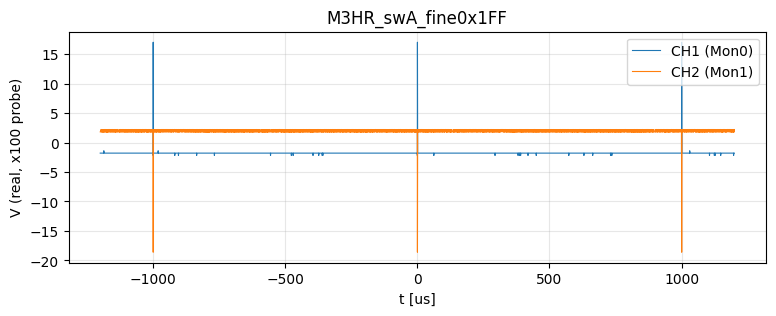

INFO    scope capture 205905_M3HR_swA_fine0x1FF: {'DEL CH1,CH2': 4e-07}


  DEL CH1,CH2    = 4e-07


WARNING psu1          COM15  watchdog: get_psu_data(0) returned -11 - purging + retrying
WARNING psu3          COM17  watchdog: get_psu_data(0) returned -13 - purging + retrying
WARNING psu4          COM18  watchdog: get_psu_data(0) returned -13 - purging + retrying
INFO    swA           COM9   setting switch 0 fine rise delay to 0


In [24]:
FINE_STEPS = [0x000, 0x080, 0x100, 0x180, 0x1FF]
# NO scope_autoset() in this sweep (deliberate): DEL compares ps-level
# edge shifts - scale + timebase must stay FIXED across steps; set the
# zoom by hand (or one AUTO) before the first step and leave it.
# CHANGE swA: oscillator 0 -> 1 kHz for the fine-delay sweep
with swA.thread_lock:
    swA.set_frequency_khz(0, RAMP_FREQ_KHZ)
scope_timebase_for(1e3)
for fine in FINE_STEPS:
    # CHANGE swA: switch 0 fine rise delay -> next step (11 ps/LSB)
    with swA.thread_lock:
        swA.set_switch_rise_delay_fine(0, fine)
    expect_ps = fine * swA.SWITCH_DELAY_FINE_SCALE * 1e12
    print(f"fine 0x{fine:03X} -> expected edge shift {expect_ps:7.0f} ps")
    scope_capture(f"M3HR_swA_fine0x{fine:03X}",
                  meas=(("DEL", "CH1,CH2"),))
    if not SIM:
        input("  M3-HR row: measured edge shift into the guide table, "
              "ENTER for next")
    dog.check()
# CHANGE swA: fine rise delay -> 0 (reset)
with swA.thread_lock:
    swA.set_switch_rise_delay_fine(0, 0)

## M3-A + M5-A — amplitude ramp, then envelope (swA, one cell)

First half = **M3-A**: recipe ramp of psu3 ch0 to 100 V at 1 kHz,
I/P print + RTIM/FTIM capture (guide 4B M3-A row). Second half =
**M5-A**: doubling ladder toward 500 kHz — V/I/P printed and
FREQ/PDCY/PEAK captured per step (guide 4B M5-A rows; PDCY exposes
the SWHR width trap — confirmed 2026-07-06: width stays ~500 ns,
duty is NOT 50 %).

INFO    swA           COM9   setting oscillator 0 period to 99998 (~1000.0 Hz)
INFO    psu3          COM17  setting PSU0 output voltage to 10.000 V
WARNING psu1          COM15  watchdog: get_psu_data(0) returned -13 - purging + retrying
WARNING psu1          COM15  watchdog: get_psu_data(1) returned -11 - purging + retrying
WARNING psu2          COM16  watchdog: get_psu_data(0) returned -14 - purging + retrying
WARNING psu4          COM18  watchdog: get_psu_data(0) returned -14 - purging + retrying
INFO    psu3          COM17  setting PSU0 output voltage to 20.000 V
WARNING psu1          COM15  watchdog: get_psu_data(1) returned -11 - purging + retrying
WARNING psu2          COM16  watchdog: get_psu_data(0) returned -11 - purging + retrying
WARNING psu2          COM16  watchdog: get_psu_data(1) returned -11 - purging + retrying
WARNING psu3          COM17  watchdog: get_psu_data(0) returned -11 - purging + retrying
WARNING psu3          COM17  watchdog: get_psu_data(1) returned -11 - p

M3-A point: 100.0 V  I = 0.08 mA  P = 0.01 W
autoset done, error queue: 0,"No error"


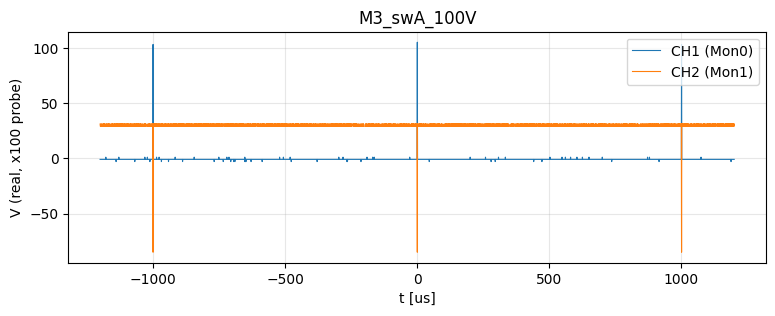

INFO    scope capture 210244_M3_swA_100V: {'RTIM CH1': 8e-07, 'FTIM CH1': 8e-07}
INFO    swA           COM9   setting oscillator 0 period to 49998 (~2000.0 Hz)


  RTIM CH1       = 8e-07
  FTIM CH1       = 8e-07


WARNING psu1          COM15  watchdog: get_psu_data(0) returned -11 - purging + retrying
WARNING psu1          COM15  watchdog: get_psu_data(1) returned -11 - purging + retrying
WARNING psu4          COM18  watchdog: get_psu_data(0) returned -14 - purging + retrying


       2 kHz | psu3 ch0:  100.0 V  I =    0.16 mA  P =   0.02 W
autoset done, error queue: 0,"No error"


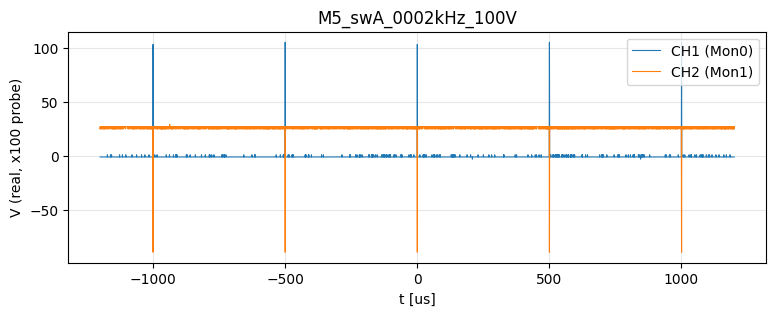

INFO    scope capture 210251_M5_swA_0002kHz_100V: {'FREQ CH1': nan, 'PDCY CH1': nan, 'PEAK CH1': 108.0}
INFO    swA           COM9   setting oscillator 0 period to 24998 (~4000.0 Hz)


  FREQ CH1       = nan
  PDCY CH1       = nan
  PEAK CH1       = 108


WARNING psu1          COM15  watchdog: get_psu_data(0) returned -11 - purging + retrying
WARNING psu1          COM15  watchdog: get_psu_data(1) returned -11 - purging + retrying


       4 kHz | psu3 ch0:  100.0 V  I =    0.34 mA  P =   0.03 W
autoset done, error queue: 0,"No error"


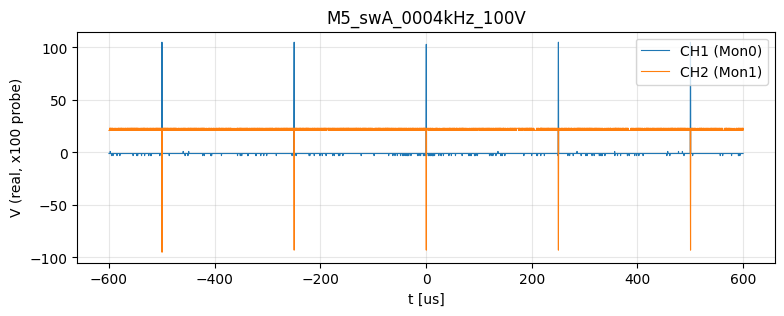

INFO    scope capture 210257_M5_swA_0004kHz_100V: {'FREQ CH1': nan, 'PDCY CH1': nan, 'PEAK CH1': 108.0}
INFO    swA           COM9   setting oscillator 0 period to 12498 (~8000.0 Hz)


  FREQ CH1       = nan
  PDCY CH1       = nan
  PEAK CH1       = 108


WARNING psu4          COM18  watchdog: get_psu_data(0) returned -11 - purging + retrying
WARNING psu4          COM18  watchdog: get_psu_data(1) returned -11 - purging + retrying


       8 kHz | psu3 ch0:  100.0 V  I =    0.69 mA  P =   0.07 W
autoset done, error queue: 0,"No error"


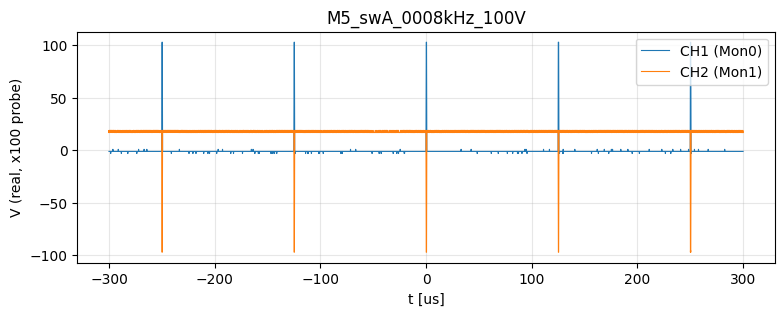

INFO    scope capture 210305_M5_swA_0008kHz_100V: {'FREQ CH1': 8001.6, 'PDCY CH1': 0.4, 'PEAK CH1': 106.0}
INFO    swA           COM9   setting oscillator 0 period to 6248 (~16000.0 Hz)


  FREQ CH1       = 8001.6
  PDCY CH1       = 0.4
  PEAK CH1       = 106


WARNING psu4          COM18  watchdog: get_psu_data(0) returned -14 - purging + retrying


      16 kHz | psu3 ch0:  100.0 V  I =    1.40 mA  P =   0.14 W
autoset done, error queue: 0,"No error"


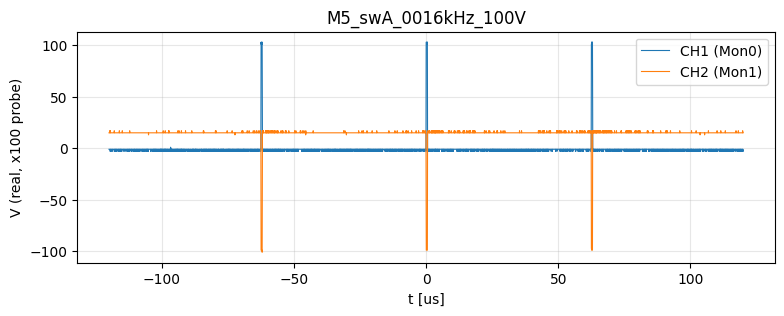

INFO    scope capture 210312_M5_swA_0016kHz_100V: {'FREQ CH1': 16000.0, 'PDCY CH1': 0.8322663, 'PEAK CH1': 106.0}
INFO    swA           COM9   setting oscillator 0 period to 3123 (~32000.0 Hz)


  FREQ CH1       = 16000
  PDCY CH1       = 0.832266
  PEAK CH1       = 106


WARNING psu1          COM15  watchdog: get_psu_data(0) returned -11 - purging + retrying
WARNING psu2          COM16  watchdog: get_psu_data(0) returned -11 - purging + retrying
WARNING psu3          COM17  watchdog: get_psu_data(0) returned -14 - purging + retrying


      32 kHz | psu3 ch0:  100.0 V  I =    2.79 mA  P =   0.28 W
autoset done, error queue: 0,"No error"


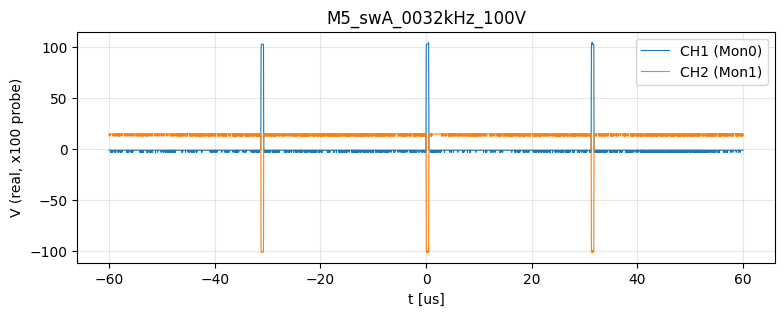

INFO    scope capture 210319_M5_swA_0032kHz_100V: {'FREQ CH1': 32000.0, 'PDCY CH1': 1.600512, 'PEAK CH1': 108.0}
INFO    swA           COM9   setting oscillator 0 period to 1560 (~64020.5 Hz)


  FREQ CH1       = 32000
  PDCY CH1       = 1.60051
  PEAK CH1       = 108
      64 kHz | psu3 ch0:  100.0 V  I =    5.60 mA  P =   0.56 W
autoset done, error queue: 0,"No error"


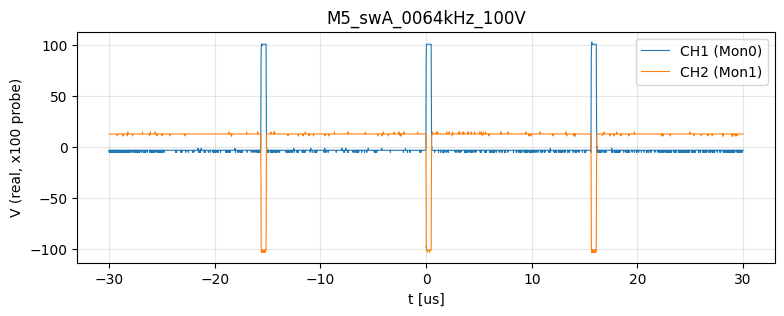

INFO    scope capture 210326_M5_swA_0064kHz_100V: {'FREQ CH1': 64020.49, 'PDCY CH1': 3.265045, 'PEAK CH1': 108.0}
INFO    swA           COM9   setting oscillator 0 period to 779 (~128041.0 Hz)


  FREQ CH1       = 64020.5
  PDCY CH1       = 3.26505
  PEAK CH1       = 108
     128 kHz | psu3 ch0:    0.0 V  I =    0.00 mA  P =   0.00 W
autoset done, error queue: 0,"No error"


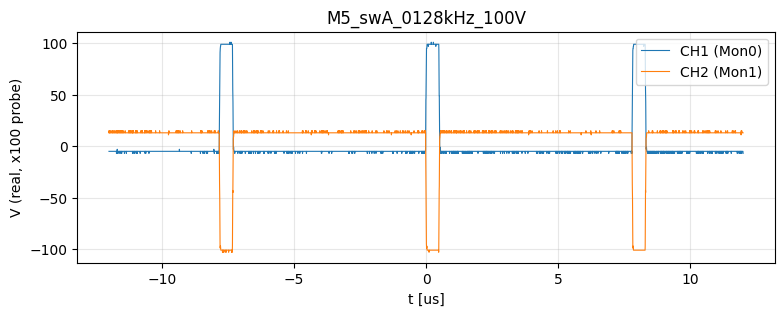

INFO    scope capture 210332_M5_swA_0128kHz_100V: {'FREQ CH1': 128041.0, 'PDCY CH1': 6.403689, 'PEAK CH1': 108.0}
INFO    swA           COM9   setting oscillator 0 period to 389 (~255754.5 Hz)


  FREQ CH1       = 128041
  PDCY CH1       = 6.40369
  PEAK CH1       = 108


WARNING psu1          COM15  watchdog: get_psu_data(0) returned -14 - purging + retrying


     256 kHz | psu3 ch0:  100.0 V  I =   22.35 mA  P =   2.24 W
autoset done, error queue: 0,"No error"


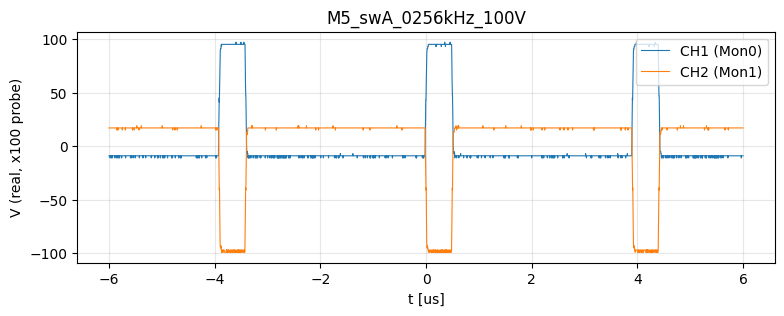

INFO    scope capture 210339_M5_swA_0256kHz_100V: {'FREQ CH1': 255754.5, 'PDCY CH1': 12.89003, 'PEAK CH1': 108.0}
INFO    swA           COM9   setting oscillator 0 period to 198 (~500000.0 Hz)


  FREQ CH1       = 255754
  PDCY CH1       = 12.89
  PEAK CH1       = 108
     500 kHz | psu3 ch0:  100.0 V  I =   43.56 mA  P =   4.36 W
autoset done, error queue: 0,"No error"


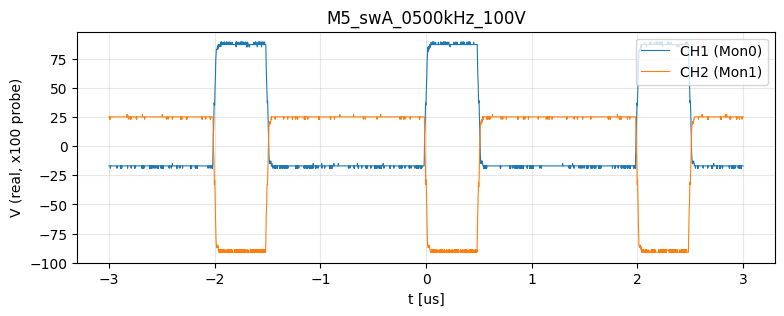

INFO    scope capture 210345_M5_swA_0500kHz_100V: {'FREQ CH1': 500125.0, 'PDCY CH1': 25.11256, 'PEAK CH1': 108.0}
INFO    swA           COM9   setting oscillator 0 period to 99998 (~1000.0 Hz)


  FREQ CH1       = 500125
  PDCY CH1       = 25.1126
  PEAK CH1       = 108
swA envelope open up to 500 kHz at 100 V


In [29]:
# NOTE (SWHR): frequency moves touch Osc0 only - timer widths do NOT
# track the period, so duty drifts with frequency. The envelope loop
# therefore captures PDCY per step (guide 4B duty column); the NVM
# ladder configs (python 269-277) are the clean anchor points if the
# drift bites.
DWELL_S = 0.05 if SIM else 2.0
try:
    # CHANGE psu3 ch0 + swA: recipe ramp - 1 kHz forced, voltage in
    # 10 V steps to 100 V, watchdog after every step
    ramp_voltage_at_1khz(swA, psu3, psu3.PSU_POS, 100.0, step_v=10.0,
                         dwell_s=DWELL_S, watchdog=dog, oscillator=0)
    with psu3.thread_lock:
        _, v_now, i_a, _ = psu3.get_psu_data(psu3.PSU_POS)
    print(f"M3-A point: {v_now:.1f} V  I = {i_a * 1000.0:.2f} mA  "
          f"P = {v_now * i_a:.2f} W")
    scope_autoset()   # V/div follows the new amplitude (M3 bench lesson)
    scope_capture("M3_swA_100V", meas=(("RTIM", "CH1"), ("FTIM", "CH1")))

    # M5-A: explicit doubling ladder - I/P + duty capture per step,
    # no ENTER pauses (fill guide 4B from the cell output).
    steps_a, f = [], RAMP_FREQ_KHZ
    while f < 500.0:
        f = min(f * 2.0, 500.0)
        steps_a.append(f)
    for f in steps_a:
        # CHANGE swA: oscillator 0 frequency -> f (timer widths NOT
        # re-fit - watch the PDCY readout for duty drift)
        with swA.thread_lock:
            swA.set_frequency_khz(0, f)
        time.sleep(DWELL_S)
        breaches = dog.check()
        if breaches:
            b = breaches[0]
            print(f"{f:8g} kHz | WATCHDOG: {b['current_ma']:.1f} mA / "
                  f"{b['power_w']:.1f} W at breach (setpoint stepped down)")
        else:
            with psu3.thread_lock:
                _, v_now, i_a, _ = psu3.get_psu_data(psu3.PSU_POS)
            print(f"{f:8g} kHz | psu3 ch0: {v_now:6.1f} V  "
                  f"I = {i_a * 1000.0:7.2f} mA  P = {v_now * i_a:6.2f} W")
        scope_autoset()
        scope_capture(f"M5_swA_{f:04.0f}kHz_100V",
                      meas=(("FREQ", "CH1"), ("PDCY", "CH1"),
                            ("PEAK", "CH1")))
        if breaches:
            raise WatchdogBreach(
                f"swA envelope stopped at {f:g} kHz (watchdog breach)")
    print(f"swA envelope open up to {steps_a[-1]:g} kHz at 100 V")
except WatchdogBreach as e:
    print(f"swA ENVELOPE EDGE: {e}")
finally:
    # CHANGE swA: park oscillator 0 at 1 kHz
    with swA.thread_lock:
        swA.set_frequency_khz(0, RAMP_FREQ_KHZ)

In [31]:
# swA block teardown -> standby configs (PSUs first, then swA).
# CHANGE psu3+psu4: outputs -> 0 V, then NVM standby config 0
for name, p in (("psu3", psu3), ("psu4", psu4)):
    with p.thread_lock:
        p.purge()   # flush a possibly-poisoned RX buffer BEFORE commanding
        p.set_psu_output_voltage(p.PSU_POS, 0.0)
        p.set_psu_output_voltage(p.PSU_NEG, 0.0)
        status = p.load_current_config(STANDBY_CONFIG)
    print(f"{name} -> standby config (status {status})")
# CHANGE swA: NVM standby config 0 (after the PSUs)
with swA.thread_lock:
    swA.purge()
    status = swA.load_current_config(STANDBY_CONFIG)
print(f"swA  -> standby config (status {status})")
print("swA block parked")


INFO    psu3          COM17  setting PSU0 output voltage to 0.000 V
ERROR   psu3          COM17  failed to set PSU0 output voltage: status -13
INFO    psu3          COM17  setting PSU1 output voltage to 0.000 V
ERROR   psu3          COM17  failed to set PSU1 output voltage: status -13
INFO    psu3          COM17  loading config slot 0
ERROR   psu3          COM17  failed to load config 0: status -13
INFO    psu4          COM18  setting PSU0 output voltage to 0.000 V
INFO    psu4          COM18  setting PSU1 output voltage to 0.000 V
INFO    psu4          COM18  loading config slot 0
INFO    swA           COM9   loading config slot 0


psu3 -> standby config (status -13)
psu4 -> standby config (status 0)
swA  -> standby config (status 0)
swA block parked


# Emergency shutdown / end of session

PSUs down FIRST, then switches — always.

In [32]:
def emergency_shutdown():
    # CHANGE all PSUs: outputs -> 0 V, output + device enables OFF (ALWAYS first)
    for name, p in [("psu1", psu1), ("psu2", psu2), ("psu3", psu3), ("psu4", psu4)]:
        try:
            with p.thread_lock:
                # Flush FIRST: 2026-07-06 session end had -13 on every
                # command of psu1-3 (poisoned buffer) - park failed.
                p.purge()
                s1 = p.set_psu_output_voltage(p.PSU_POS, 0.0)
                s2 = p.set_psu_output_voltage(p.PSU_NEG, 0.0)
                s3 = p.set_psu_enable(False, False)
                s4 = p.set_device_enable(False)
            if any(s != p.NO_ERR for s in (s1, s2, s3, s4)):
                print(f"{name}: PARK NOT CONFIRMED (statuses "
                      f"{(s1, s2, s3, s4)}) - purge + re-run this cell!")
            else:
                print(f"{name}: outputs 0 V, disabled")
        except Exception as e:
            print(f"{name}: SHUTDOWN FAILED: {e}")
    # CHANGE both switches: device enable OFF (after the PSUs)
    for name, s in [("swA", swA), ("swB", swB)]:
        try:
            with s.thread_lock:
                s.purge()
                s.set_device_enable(False)
            print(f"{name}: disabled")
        except Exception as e:
            print(f"{name}: SHUTDOWN FAILED: {e}")
    # CHANGE all devices: NVM standby config 0 -> defined parked state
    for name, d in [("psu1", psu1), ("psu2", psu2), ("psu3", psu3),
                    ("psu4", psu4), ("swA", swA), ("swB", swB)]:
        try:
            with d.thread_lock:
                d.load_current_config(0)
            print(f"{name}: standby config loaded")
        except Exception as e:
            print(f"{name}: standby config FAILED: {e}")

emergency_shutdown()


INFO    psu1          COM15  setting PSU0 output voltage to 0.000 V
ERROR   psu1          COM15  failed to set PSU0 output voltage: status -13
INFO    psu1          COM15  setting PSU1 output voltage to 0.000 V
ERROR   psu1          COM15  failed to set PSU1 output voltage: status -13
INFO    psu1          COM15  setting PSU enable to psu0=False, psu1=False
ERROR   psu1          COM15  failed to set PSU enable: status -13
INFO    psu1          COM15  setting device enable to False
ERROR   psu1          COM15  failed to set device enable: status -13
INFO    psu2          COM16  setting PSU0 output voltage to 0.000 V
ERROR   psu2          COM16  failed to set PSU0 output voltage: status -13
INFO    psu2          COM16  setting PSU1 output voltage to 0.000 V
ERROR   psu2          COM16  failed to set PSU1 output voltage: status -13
INFO    psu2          COM16  setting PSU enable to psu0=False, psu1=False
ERROR   psu2          COM16  failed to set PSU enable: status -13
INFO    psu2       

psu1: outputs 0 V, disabled
psu2: outputs 0 V, disabled
psu3: outputs 0 V, disabled
psu4: outputs 0 V, disabled
Hello
swA: disabled
Hello
swB: disabled
psu1: standby config loaded
psu2: standby config loaded
psu3: standby config loaded


INFO    swA           COM9   loading config slot 0
INFO    swB           COM10  loading config slot 0


psu4: standby config loaded
swA: standby config loaded
swB: standby config loaded


In [15]:
for name, dev in ALL:
    dev.disconnect()
if SCOPE is not None:
    SCOPE.close()
    print("scope connection closed")
print("all disconnected - session over. Debrief into the guide TODAY.")

WARNING psu1          COM15  close_port returned -3
INFO    psu1          COM15  disconnected
WARNING psu2          COM16  close_port returned -3
INFO    psu2          COM16  disconnected
WARNING psu3          COM17  close_port returned -3
INFO    psu3          COM17  disconnected
WARNING psu4          COM18  close_port returned -3
INFO    psu4          COM18  disconnected
WARNING swA           COM9   close_port returned -3
INFO    swA           COM9   disconnected
WARNING swB           COM10  close_port returned -3
INFO    swB           COM10  disconnected


scope connection closed
all disconnected - session over. Debrief into the guide TODAY.
